In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scanpy as sc
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, spearmanr

import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_RUNS        = 10
N_CLUSTERS    = 3   # number of clusters for reproducibility analysis
CONCENTRATION = '10'
TCDG          = 1000
RESULTS_DIR   = f'{paths.RESULTS_DIR}/reproducibility_drug'

SHERLOCK_KWARGS = dict(
    batch_size          = 4096,
    num_workers         = 0,
    num_epochs          = 1000,
    use_conditions      = True,
    validate_every      = 50,
    l0_lambda           = 200,
    patience            = 1000,
    rho_init            = False,
    ntc_lambda          = 1.0,
    latent_dim          = 8,
    debug               = True,
    n_epochs_l0_warmup  = 200,
    rank                = 3,
)

os.makedirs(f'{RESULTS_DIR}/figures',  exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/matrices', exist_ok=True)
print(f'Device: {DEVICE}  Results: {RESULTS_DIR}')

Device: cuda  Results: results/reproducibility_drug


## Data loading

In [4]:
slk.configs.reset_config()
slk.configs.set_config('ntc_label',      'DMSO')
slk.configs.set_config('pert_key',       'drug')
slk.configs.set_config('treatment_key',  'tcell_treatment')
slk.configs.set_config('untreated_label','NoT')

data = sc.read_h5ad(f'{paths.DATA_DIR}/gbm/bt333_degs_tcell_{CONCENTRATION}_{TCDG}.h5ad')
data = data[~data.obs['drug'].isna()].copy()
data = data[
    (data.obs['concentration'] == CONCENTRATION) | (data.obs['drug'] == 'DMSO')
].copy()

slk.pp.slk_prepare_data(
    data, pert_key='drug', ntc_label='DMSO', inplace=True,
    treatment_key='tcell_treatment', untreated_label='NoT', force=True
)

p_key     = slk.configs.get_config('pert_key')
NTC       = slk.configs.get_config('ntc_label')
c_key     = slk.configs.get_config('treatment_key')
c_ntc_key = slk.configs.get_config('untreated_label')

print(f'Cells: {data.n_obs}   Genes: {data.n_vars}')
print(f'Perturbations (non-DMSO): {data.obs[p_key].nunique() - 1}')
print(f'Conditions: {sorted(data.obs[c_key].unique())}')

Cells: 35511   Genes: 2894
Perturbations (non-DMSO): 11
Conditions: ['0.5T', 'NoT']


In [5]:
slk.pp.treat_effect(
    data, label_col='drug', control_label='DMSO',
    method='perturbseq', inplace=True, key='treat_effect',
)

100%|██████████| 11/11 [00:01<00:00,  8.18it/s]


## Part 1 — Reproducibility loop

Train `N_RUNS` independent models with the same hyper-parameters.  
Per run we save:
- `W`, `rho_corr` / `z_corr` matrices
- Counterfactual effect sizes per condition (for bipartite reproducibility)
- Condition-perturbation interaction matrix (CFS)
- ATE correlation + full ATE predictions (for cross-run comparison)

The single best-ATE model is saved to `best_model.pth` for final figures.

> **Tip**: skip this section if matrices already exist and jump to *Part 2 — Load matrices*.


Drug run 1/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [12:02<00:00,  1.38it/s, ATE=0.6436, CE=0.0270, ELBO=1828.9192, KLw=1.00, R2_ntc=0.7615, R2_p=0.7678, acc=0.991, pi25=0.12, pi99=0.99, tau=0.300]


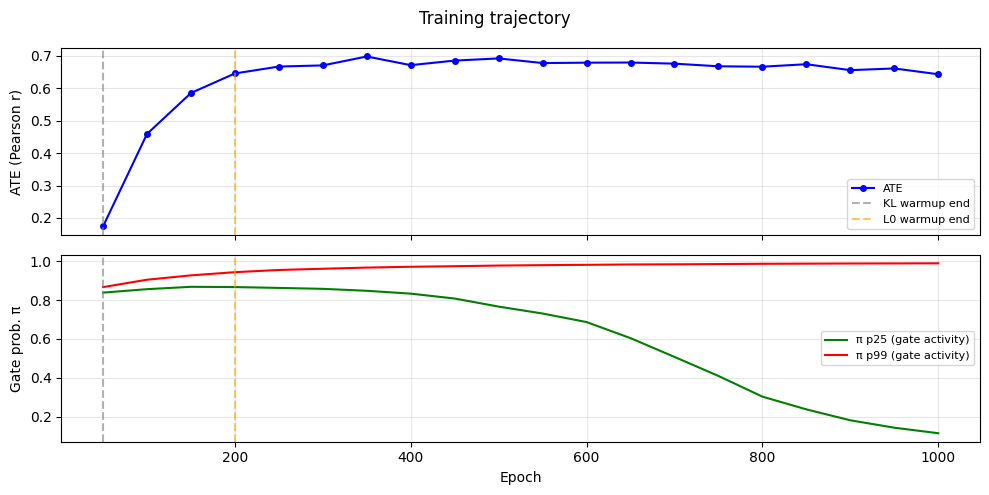

  New best model: ATE r=0.6512
  Saved run 1 (ATE r=0.6512)

Drug run 2/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [10:14<00:00,  1.63it/s, ATE=0.6659, CE=0.0257, ELBO=1829.1457, KLw=1.00, R2_ntc=0.7377, R2_p=0.7749, acc=0.992, pi25=0.17, pi99=0.99, tau=0.300]


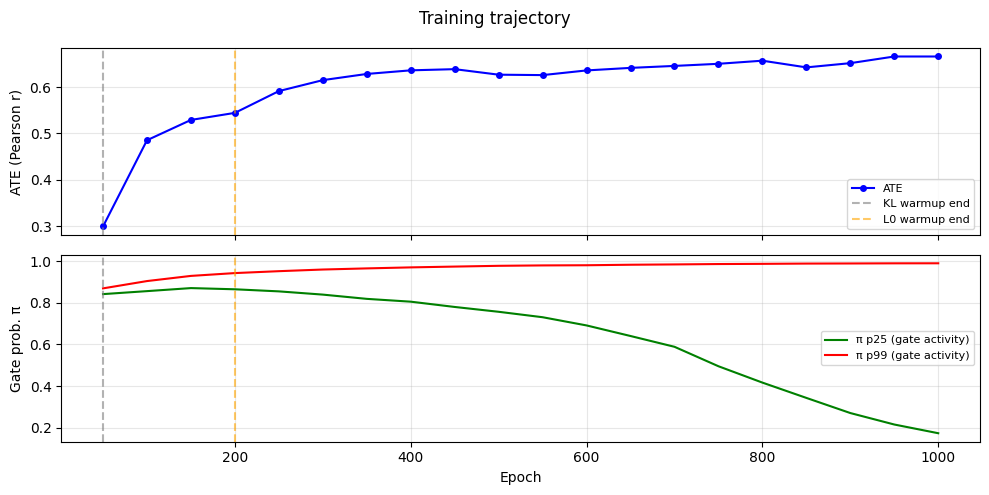

  New best model: ATE r=0.6616
  Saved run 2 (ATE r=0.6616)

Drug run 3/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [10:08<00:00,  1.64it/s, ATE=0.6207, CE=0.0318, ELBO=1830.3346, KLw=1.00, R2_ntc=0.7124, R2_p=0.7645, acc=0.990, pi25=0.07, pi99=0.99, tau=0.300]


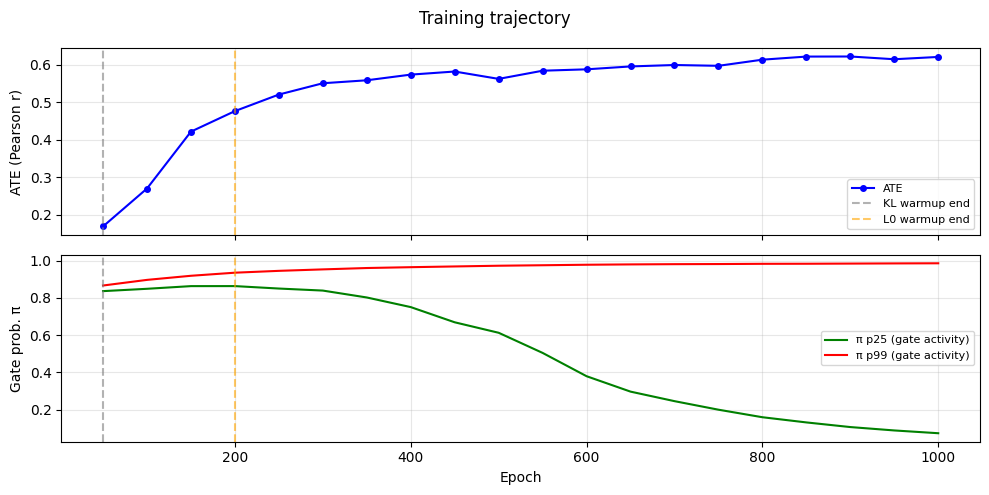

  Saved run 3 (ATE r=0.6269)

Drug run 4/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [09:56<00:00,  1.68it/s, ATE=0.6490, CE=0.0226, ELBO=1829.2331, KLw=1.00, R2_ntc=0.7809, R2_p=0.7642, acc=0.993, pi25=0.06, pi99=0.99, tau=0.300]


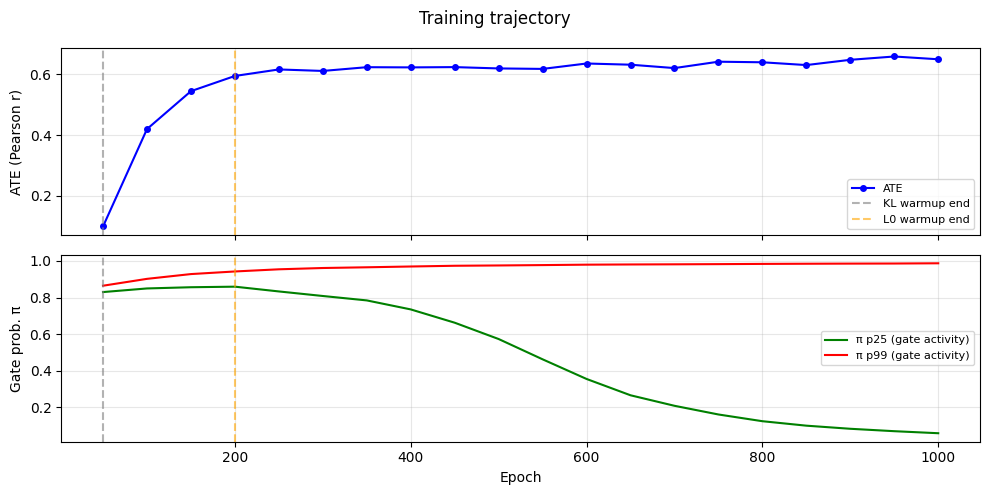

  Saved run 4 (ATE r=0.6600)

Drug run 5/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [09:57<00:00,  1.67it/s, ATE=0.6304, CE=0.0311, ELBO=1829.9998, KLw=1.00, R2_ntc=0.6832, R2_p=0.7682, acc=0.989, pi25=0.24, pi99=0.99, tau=0.300]


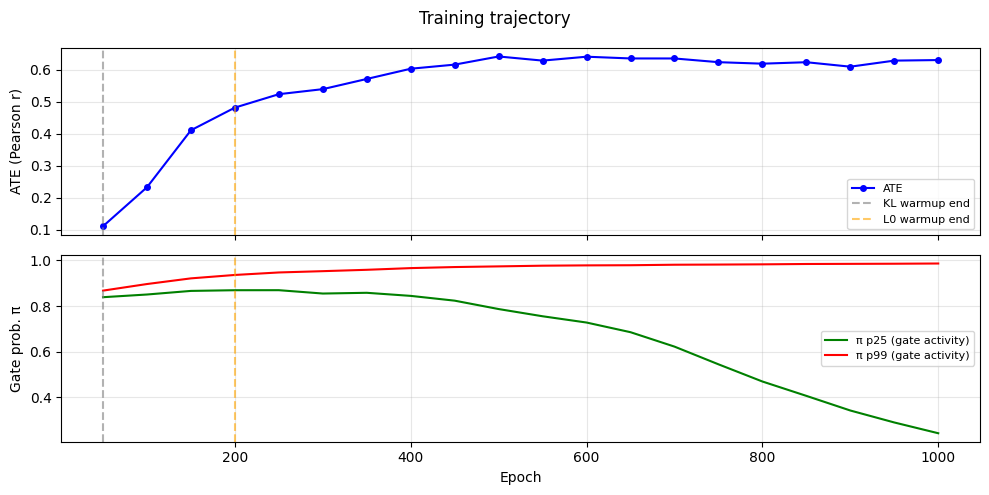

  Saved run 5 (ATE r=0.6150)

Drug run 6/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [10:18<00:00,  1.62it/s, ATE=0.6851, CE=0.0307, ELBO=1829.6990, KLw=1.00, R2_ntc=0.7027, R2_p=0.7733, acc=0.989, pi25=0.13, pi99=0.99, tau=0.300]


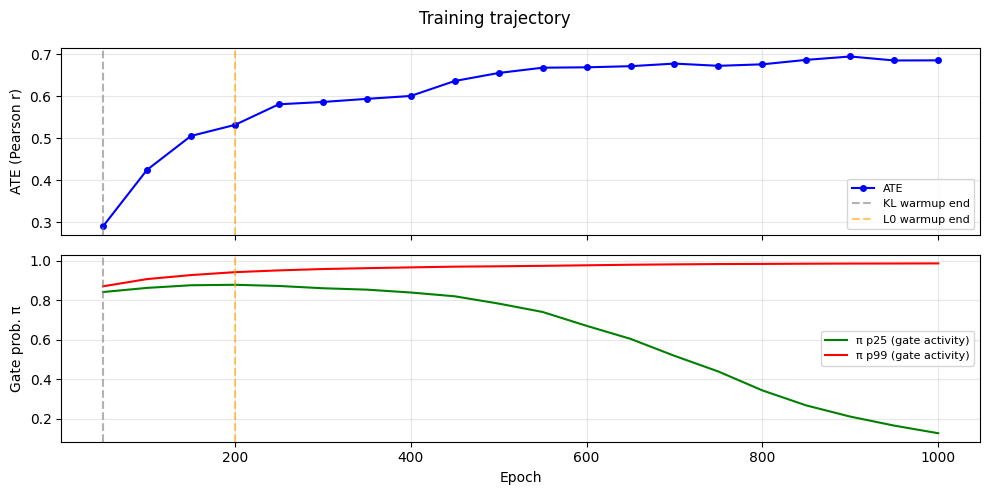

  New best model: ATE r=0.6658
  Saved run 6 (ATE r=0.6658)

Drug run 7/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [10:11<00:00,  1.64it/s, ATE=0.6294, CE=0.0247, ELBO=1829.0646, KLw=1.00, R2_ntc=0.6814, R2_p=0.7684, acc=0.992, pi25=0.13, pi99=0.99, tau=0.300]


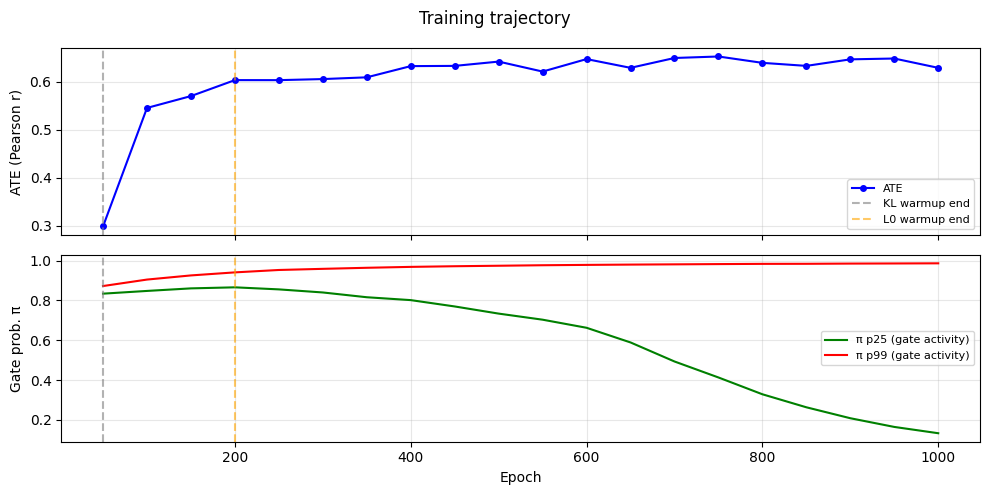

  Saved run 7 (ATE r=0.6387)

Drug run 8/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [09:55<00:00,  1.68it/s, ATE=0.6644, CE=0.0307, ELBO=1829.8847, KLw=1.00, R2_ntc=0.7089, R2_p=0.7654, acc=0.990, pi25=0.07, pi99=0.99, tau=0.300]


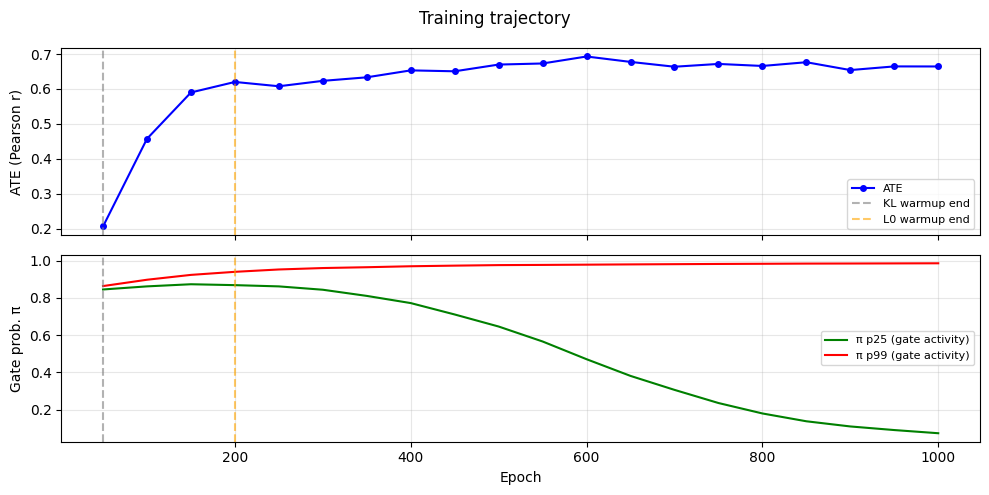

  Saved run 8 (ATE r=0.6623)

Drug run 9/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [10:03<00:00,  1.66it/s, ATE=0.6742, CE=0.0265, ELBO=1827.6954, KLw=1.00, R2_ntc=0.6054, R2_p=0.7724, acc=0.991, pi25=0.05, pi99=0.99, tau=0.300]


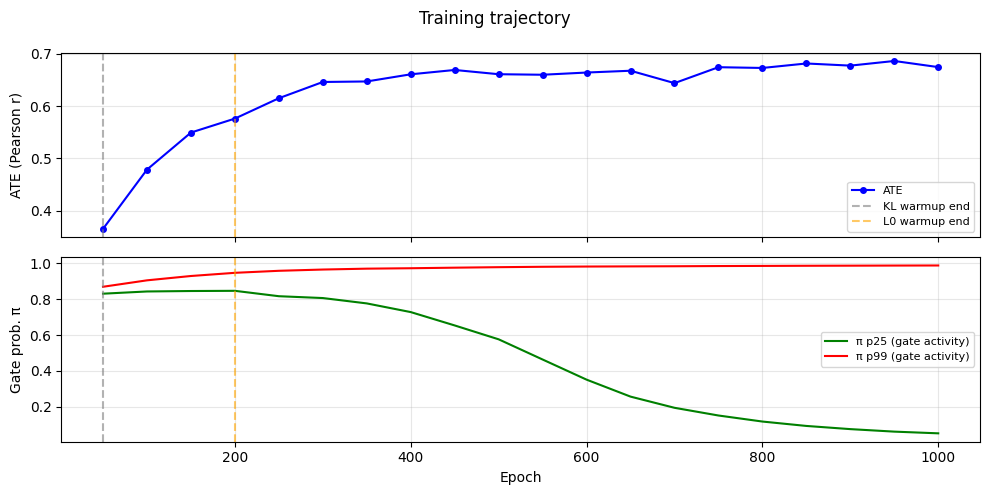

  New best model: ATE r=0.6742
  Saved run 9 (ATE r=0.6742)

Drug run 10/10
Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [10:21<00:00,  1.61it/s, ATE=0.6455, CE=0.0274, ELBO=1830.4548, KLw=1.00, R2_ntc=0.6955, R2_p=0.7699, acc=0.990, pi25=0.11, pi99=0.99, tau=0.300]


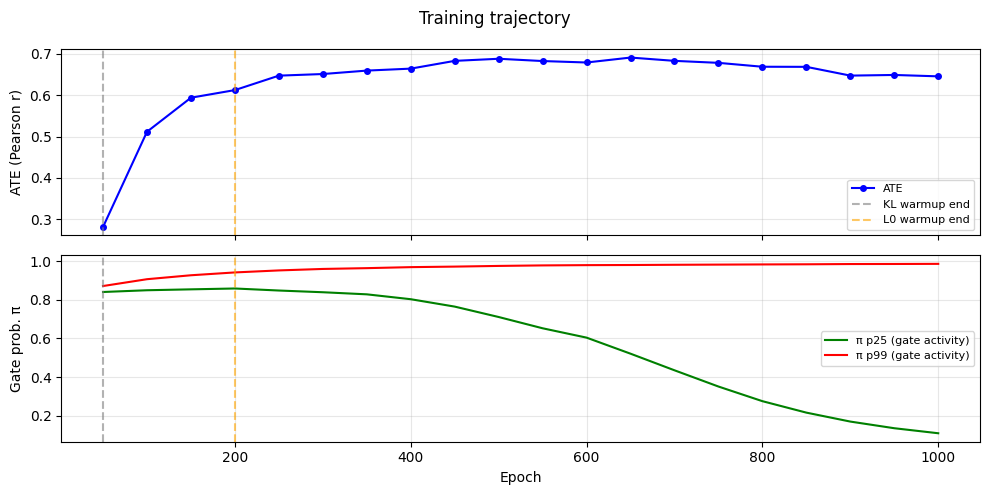

  Saved run 10 (ATE r=0.6271)

Training complete.


In [6]:
use_rerun = True

for run in range(N_RUNS):
    out_path = f'{RESULTS_DIR}/matrices/run_{run}.npz'
    if os.path.exists(out_path) and use_rerun:
        print(f'Run {run+1}: already saved, skipping.')
        continue

    print(f"\n{'='*50}\nDrug run {run+1}/{N_RUNS}\n{'='*50}")
    out   = slk.tl.run_single(data, device=DEVICE, seed=run, **SHERLOCK_KWARGS)
    model = out['model']

    slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=DEVICE)
    res = data.uns['results']

    W          = np.asarray(res['W'],         dtype=float)
    rho_corr   = np.asarray(res['rho_corr'],  dtype=float)
    z_corr     = np.asarray(res['z_corr'],    dtype=float)
    rho_perts  = np.asarray(res['rho_perts'])
    cond_names = list(res['conditions'])
    cf_sizes   = [np.asarray(cf, dtype=float) for cf in res['counterfactual_effect_size']]
    cfs_mat    = np.asarray(res['condition_perturbation_interaction'], dtype=float)

    # ATE: predicted vs observed treatment effect correlation
    ate      = model.predict_counterfactual_effects(
        data, n_centroids=25, observed_effect=data.uns['treat_effect'],
    )
    ate_r    = float(ate['corr'])
    pred_df  = ate['predicted_df']

    # ev_sig qvals per condition (significant gene-set Jaccard reproducibility)
    for ci in range(len(cond_names)):
        slk.tl.ev_sig(data, cond_idx=ci)
        qvals = np.asarray(data.uns['results']['ev_results'][ci]['qvals'], dtype=float)
        np.save(f'{RESULTS_DIR}/matrices/run_{run}_evqvals_{ci}.npy', qvals)

    # Save matrices
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_W.npy',        W)
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy', rho_corr)
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_z_corr.npy',   z_corr)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_perts.txt',  rho_perts,  fmt='%s')
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_conds.txt',  cond_names, fmt='%s')
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_cfs_mat.npy',  cfs_mat)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_r.txt',  [ate_r],    fmt='%.6f')
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_ate_pred.npy', pred_df.values)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_perts.txt', list(pred_df.index), fmt='%s')
    for ci, cf in enumerate(cf_sizes):
        np.save(f'{RESULTS_DIR}/matrices/run_{run}_cf_{ci}.npy', cf)
    np.savez(out_path)  # sentinel

    # Keep the best-ATE model
    best_r_path = f'{RESULTS_DIR}/matrices/best_ate_r.txt'
    current_best = float(np.loadtxt(best_r_path)) if os.path.exists(best_r_path) else -np.inf
    if ate_r > current_best:
        slk.tl.save_results(out, f'{RESULTS_DIR}/matrices/best_model.pth')
        np.savetxt(best_r_path, [ate_r], fmt='%.6f')
        np.savetxt(f'{RESULTS_DIR}/matrices/best_run.txt', [run], fmt='%d')
        print(f'  New best model: ATE r={ate_r:.4f}')

    print(f'  Saved run {run+1} (ATE r={ate_r:.4f})')

print('\nTraining complete.')

In [31]:
cfs_mat.shape

(11, 2, 2)

## Part 2 — Load saved matrices

Re-entry point: run from here if matrices already exist.

In [7]:
run_results = []
for run in range(N_RUNS):
    W          = np.load(f'{RESULTS_DIR}/matrices/run_{run}_W.npy')
    rho_corr   = np.load(f'{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy')
    z_corr     = np.load(f'{RESULTS_DIR}/matrices/run_{run}_z_corr.npy')
    rho_perts  = np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_perts.txt',    dtype=str, ndmin=1)
    cond_names = list(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_conds.txt', dtype=str, ndmin=1))
    cfs_mat    = np.load(f'{RESULTS_DIR}/matrices/run_{run}_cfs_mat.npy')
    ate_r      = float(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_r.txt'))
    ate_pred   = np.load(f'{RESULTS_DIR}/matrices/run_{run}_ate_pred.npy')
    ate_perts  = list(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_perts.txt', dtype=str, ndmin=1))
    n_conds    = len(cond_names)
    cf_sizes   = [np.load(f'{RESULTS_DIR}/matrices/run_{run}_cf_{ci}.npy') for ci in range(n_conds)]
    ev_qvals   = [np.load(f'{RESULTS_DIR}/matrices/run_{run}_evqvals_{ci}.npy') for ci in range(n_conds)]

    run_results.append(dict(
        run=run, W=W, rho_corr=rho_corr, z_corr=z_corr,
        rho_perts=rho_perts, cond_names=cond_names,
        cfs_mat=cfs_mat, ate_r=ate_r, ate_pred=ate_pred,
        ate_perts=ate_perts, cf_sizes=cf_sizes, ev_qvals=ev_qvals,
    ))
    print(f'Run {run+1}: ATE r={ate_r:.4f}  W {W.shape}  perts {len(rho_perts)}')

all_perts   = sorted(run_results[0]['rho_perts'].tolist())
cond_names  = run_results[0]['cond_names']
all_ate_r   = [r['ate_r'] for r in run_results]
best_run_id = int(np.argmax(all_ate_r))

print(f'\nATE r per run: {[f"{r:.4f}" for r in all_ate_r]}')
print(f'Mean ± Std: {np.mean(all_ate_r):.4f} ± {np.std(all_ate_r):.4f}')
print(f'Best run: {best_run_id+1} (ATE r={all_ate_r[best_run_id]:.4f})')
print(f'Conditions: {cond_names}')

Run 1: ATE r=0.6512  W (11, 8)  perts 11
Run 2: ATE r=0.6616  W (11, 8)  perts 11
Run 3: ATE r=0.6269  W (11, 8)  perts 11
Run 4: ATE r=0.6600  W (11, 8)  perts 11
Run 5: ATE r=0.6150  W (11, 8)  perts 11
Run 6: ATE r=0.6658  W (11, 8)  perts 11
Run 7: ATE r=0.6387  W (11, 8)  perts 11
Run 8: ATE r=0.6623  W (11, 8)  perts 11
Run 9: ATE r=0.6742  W (11, 8)  perts 11
Run 10: ATE r=0.6271  W (11, 8)  perts 11

ATE r per run: ['0.6512', '0.6616', '0.6269', '0.6600', '0.6150', '0.6658', '0.6387', '0.6623', '0.6742', '0.6271']
Mean ± Std: 0.6483 ± 0.0190
Best run: 9 (ATE r=0.6742)
Conditions: [np.str_('NoT'), np.str_('0.5T')]


## Helper functions

In [8]:
def align_groups_to_reference(ref_ng, tgt_ng):
    """Hungarian-match tgt group labels to ref group labels by shared membership."""
    common = set(ref_ng.index) & set(tgt_ng.index)
    if not common:
        return {}
    ref_labels = sorted(ref_ng['group'].unique())
    tgt_labels = sorted(tgt_ng['group'].unique())
    C = np.zeros((len(ref_labels), len(tgt_labels)), dtype=int)
    for gene in common:
        ri = ref_labels.index(ref_ng.loc[gene, 'group'])
        ti = tgt_labels.index(tgt_ng.loc[gene, 'group'])
        C[ri, ti] += 1
    row_ind, col_ind = linear_sum_assignment(C.max() - C)
    mapping = {tgt_labels[j]: ref_labels[i] for i, j in zip(row_ind, col_ind)}
    for tl in tgt_labels:
        if tl not in mapping:
            genes_in_tl = [g for g in tgt_ng.index if tgt_ng.loc[g, 'group'] == tl and g in common]
            if genes_in_tl:
                vote = {}
                for g in genes_in_tl:
                    rg = ref_ng.loc[g, 'group']
                    vote[rg] = vote.get(rg, 0) + 1
                mapping[tl] = max(vote, key=vote.get)
    return mapping


def cluster_all_runs(run_results, n_clusters, all_perts):
    clustered = []
    for rr in run_results:
        groups       = slk.tl.cluster_rho(
            data, t=n_clusters, rho_corr=rr['z_corr'],
            criterion='maxclust', show=False,
        )
        named_groups = slk.tl.group2name(groups, list(rr['rho_perts']))
        clustered.append({**rr, 'groups': groups, 'named_groups': named_groups})
    return clustered


def compute_confidence(clustered_runs, all_perts):
    ref_ng     = clustered_runs[0]['named_groups']
    ref_groups = sorted(ref_ng['group'].unique())
    n_runs     = len(clustered_runs)

    aligned = {p: [] for p in all_perts}
    for rr in clustered_runs:
        mapping = ({g: g for g in ref_groups} if rr['run'] == 0
                   else align_groups_to_reference(ref_ng, rr['named_groups']))
        ng = rr['named_groups']
        for p in all_perts:
            if p in ng.index:
                aligned[p].append(mapping.get(ng.loc[p, 'group'], -1))
            else:
                aligned[p].append(-1)

    group_cols = [f'Group {g}' for g in ref_groups]
    rows = []
    for p in all_perts:
        asn  = aligned[p]
        row  = {f'Group {g}': asn.count(g) / n_runs for g in ref_groups}
        row['modal_group'] = f'Group {max(ref_groups, key=lambda g: asn.count(g))}'
        row['max_conf']    = max(asn.count(g) for g in ref_groups) / n_runs
        row['unassigned']  = asn.count(-1) / n_runs
        rows.append({'perturbation': p, **row})

    df = pd.DataFrame(rows).set_index('perturbation')
    return df.sort_values(['modal_group', 'max_conf'], ascending=[True, False]), group_cols


def jaccard(labels_i, labels_j):
    n      = len(labels_i)
    same_i = labels_i[:, None] == labels_i[None, :]
    same_j = labels_j[:, None] == labels_j[None, :]
    triu   = np.triu_indices(n, k=1)
    a, b   = same_i[triu], same_j[triu]
    union  = int((a | b).sum())
    return int((a & b).sum()) / union if union > 0 else np.nan


def compute_pairwise_similarity(run_results, clustered_runs, all_perts):
    """W co-activation, rho, and cluster Jaccard for every run pair."""
    n_runs = len(run_results)
    pairs  = list(combinations(range(n_runs), 2))
    w_corrs, rho_corrs, jac_raw, jac_aln = [], [], [], []

    for i, j in pairs:
        ri, rj = run_results[i], run_results[j]

        Ci   = ri['W'] @ ri['W'].T
        Cj   = rj['W'] @ rj['W'].T
        triu = np.triu_indices(Ci.shape[0], k=1)
        w_corrs.append(pearsonr(Ci[triu], Cj[triu])[0])

        fi, fj = ri['z_corr'][triu], rj['z_corr'][triu]
        valid  = np.isfinite(fi) & np.isfinite(fj)
        rho_corrs.append(pearsonr(fi[valid], fj[valid])[0])

        ci_r, cj_r = clustered_runs[i], clustered_runs[j]
        jac_raw.append(jaccard(ci_r['groups'].astype(object), cj_r['groups'].astype(object)))

        ng_i, ng_j = ci_r['named_groups'], cj_r['named_groups']
        common     = [p for p in all_perts if p in ng_i.index and p in ng_j.index]
        mapping_ij = align_groups_to_reference(ng_i, ng_j)
        mp_i = np.array([ng_i.loc[p, 'group'] for p in common], dtype=object)
        mp_j = np.array([mapping_ij.get(ng_j.loc[p, 'group'], -1) for p in common], dtype=object)
        valid_mask = mp_j != -1
        jac_aln.append(jaccard(mp_i[valid_mask], mp_j[valid_mask]))

    return pairs, w_corrs, rho_corrs, jac_raw, jac_aln

## Part 3 — W and rho reproducibility

For every run pair:
- **W co-activation Pearson r**: upper triangle of `W @ Wᵀ`
- **rho Pearson r**: upper triangle of `z_corr`

In [9]:
clustered_runs = cluster_all_runs(run_results, N_CLUSTERS, all_perts)
pairs, w_corrs, rho_corrs, jac_raw, jac_aln = compute_pairwise_similarity(
    run_results, clustered_runs, all_perts
)

print('Pairwise W co-activation Pearson r:')
print(f'  Mean ± Std: {np.mean(w_corrs):.4f} ± {np.std(w_corrs):.4f}')
print(f'  Min / Max : {np.min(w_corrs):.4f} / {np.max(w_corrs):.4f}')

print('\nPairwise rho (z_corr) Pearson r:')
valid_rho = [v for v in rho_corrs if np.isfinite(v)]
print(f'  Mean ± Std: {np.mean(valid_rho):.4f} ± {np.std(valid_rho):.4f}')
print(f'  Min / Max : {np.min(valid_rho):.4f} / {np.max(valid_rho):.4f}')

Pairwise W co-activation Pearson r:
  Mean ± Std: 0.8473 ± 0.0623
  Min / Max : 0.7104 / 0.9448

Pairwise rho (z_corr) Pearson r:
  Mean ± Std: 0.8473 ± 0.0980
  Min / Max : 0.5330 / 0.9606


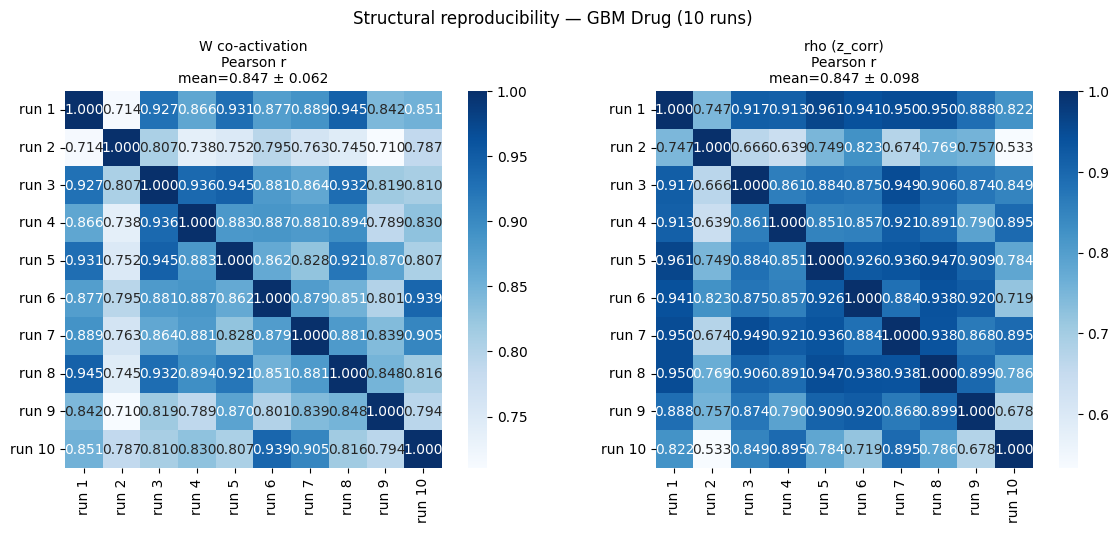

In [10]:
def to_matrix(values, n_runs, pairs):
    M = np.full((n_runs, n_runs), np.nan)
    np.fill_diagonal(M, 1.0)
    for (i, j), v in zip(pairs, values):
        M[i, j] = v
        M[j, i] = v
    return M

W_mat  = to_matrix(w_corrs,  N_RUNS, pairs)
R_mat  = to_matrix(rho_corrs, N_RUNS, pairs)
run_labels = [f'run {k+1}' for k in range(N_RUNS)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title in zip(
    axes,
    [W_mat, R_mat],
    ['W co-activation\nPearson r', 'rho (z_corr)\nPearson r'],
):
    off = mat[~np.eye(N_RUNS, dtype=bool)]
    sns.heatmap(
        mat, ax=ax, cmap='Blues', annot=(N_RUNS <= 12), fmt='.3f',
        vmin=np.nanmin(off), vmax=1.0,
        xticklabels=run_labels, yticklabels=run_labels, square=True,
    )
    ax.set_title(f'{title}\nmean={np.nanmean(off):.3f} ± {np.nanstd(off):.3f}', fontsize=10)

fig.suptitle(f'Structural reproducibility — GBM Drug ({N_RUNS} runs)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/W_rho_heatmaps.png', bbox_inches='tight', dpi=150)
plt.show()

## Part 4 — Clustering reproducibility (N_CLUSTERS = 3)

Cluster all runs with `N_CLUSTERS` groups.  
Metrics:
- Per-perturbation group **confidence** (fraction of runs in modal group)
- Pairwise **Jaccard** (raw and Hungarian-aligned)
- **Co-membership matrix** (fraction of runs where two perturbations share a cluster)

In [11]:
confidence_df, group_cols = compute_confidence(clustered_runs, all_perts)
P_n      = len(all_perts)
pert_idx = {p: i for i, p in enumerate(all_perts)}

# Co-membership matrix
comembership = np.zeros((P_n, P_n))
for rr in clustered_runs:
    ng           = rr['named_groups']
    perts_in_run = [p for p in all_perts if p in ng.index]
    for pi in perts_in_run:
        gi = ng.loc[pi, 'group']
        for pj in perts_in_run:
            if ng.loc[pj, 'group'] == gi:
                comembership[pert_idx[pi], pert_idx[pj]] += 1
comembership /= N_RUNS
np.fill_diagonal(comembership, 1.0)

print(f'Clustering with N_CLUSTERS={N_CLUSTERS}:')
print(f'  Mean max-confidence : {confidence_df["max_conf"].mean():.3f} ± {confidence_df["max_conf"].std():.3f}')
print(f'  Stable (≥0.8)       : {(confidence_df["max_conf"] >= 0.8).sum()} / {len(confidence_df)}')
print(f'  Pairwise Jaccard (aligned) : {np.nanmean(jac_aln):.3f} ± {np.nanstd(jac_aln):.3f}')
print()
print(confidence_df.round(2).to_string())

Clustering with N_CLUSTERS=3:
  Mean max-confidence : 0.764 ± 0.225
  Stable (≥0.8)       : 6 / 11
  Pairwise Jaccard (aligned) : 0.470 ± 0.179

                     Group 1  Group 2  Group 3 modal_group  max_conf  unassigned
perturbation                                                                    
Tyrphostin9              1.0      0.0      0.0     Group 1       1.0         0.0
Abemaciclibmesylate      0.9      0.0      0.1     Group 1       0.9         0.0
Laduviglusib             0.9      0.0      0.1     Group 1       0.9         0.0
ALWII4127                0.5      0.0      0.5     Group 1       0.5         0.0
CP673451                 0.5      0.0      0.5     Group 1       0.5         0.0
BAY1217389               0.0      1.0      0.0     Group 2       1.0         0.0
STK16IN1                 0.0      1.0      0.0     Group 2       1.0         0.0
Zabedosertib             0.0      0.9      0.1     Group 2       0.9         0.0
PF06260933               0.0      0.7      0.

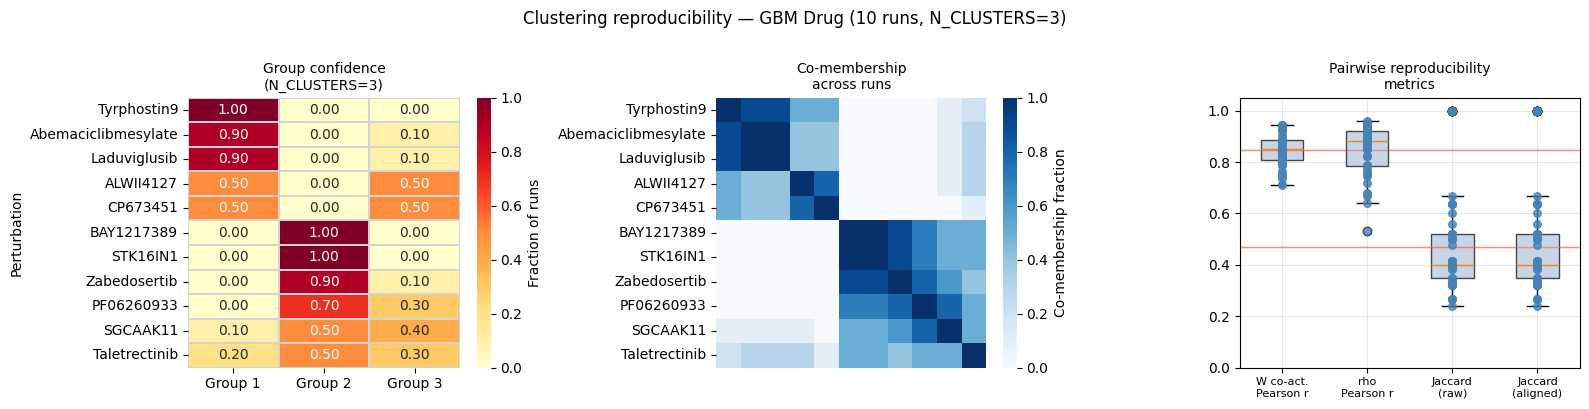

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, max(4, P_n * 0.18 + 2)))

# Confidence heatmap
sns.heatmap(
    confidence_df[group_cols], ax=axes[0],
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, linecolor='lightgray',
    cbar_kws={'label': 'Fraction of runs'},
    annot=True, fmt='.2f',
)
axes[0].set_title(f'Group confidence\n(N_CLUSTERS={N_CLUSTERS})', fontsize=10)
axes[0].set_ylabel('Perturbation')

# Co-membership heatmap
sort_order = confidence_df.index.tolist()
cm_plot    = pd.DataFrame(comembership, index=all_perts, columns=all_perts).loc[sort_order, sort_order]
sns.heatmap(
    cm_plot, ax=axes[1],
    cmap='Blues', vmin=0, vmax=1,
    xticklabels=False, yticklabels=sort_order,
    cbar_kws={'label': 'Co-membership fraction'},
    square=True,
)
axes[1].set_title('Co-membership\nacross runs', fontsize=10)

# Jaccard boxplot
for pos, (vals, title) in enumerate([
    (w_corrs,  'W co-act.\nPearson r'),
    (rho_corrs,'rho\nPearson r'),
    (jac_raw,  'Jaccard\n(raw)'),
    (jac_aln,  'Jaccard\n(aligned)'),
], 1):
    clean = [v for v in vals if np.isfinite(v)]
    axes[2].boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
    axes[2].scatter([pos]*len(clean), clean, color='steelblue', s=30, zorder=3, alpha=0.8)
    axes[2].axhline(np.mean(clean), color='tomato', lw=1, alpha=0.5)

axes[2].set_xticks(range(1, 5))
axes[2].set_xticklabels(['W co-act.\nPearson r', 'rho\nPearson r',
                          'Jaccard\n(raw)', 'Jaccard\n(aligned)'], fontsize=8)
axes[2].set_title('Pairwise reproducibility\nmetrics', fontsize=10)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'Clustering reproducibility — GBM Drug ({N_RUNS} runs, N_CLUSTERS={N_CLUSTERS})',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/clustering_reproducibility_k{N_CLUSTERS}.png',
            bbox_inches='tight', dpi=150)
plt.show()

## Part 5 — ATE reproducibility

For every run pair, compute Pearson r of the flattened ATE prediction matrices
(all perturbations × all genes).

In [13]:
# Pairwise ATE prediction correlation
ate_pred_corrs = []
for i, j in pairs:
    pi = run_results[i]['ate_pred']
    pj = run_results[j]['ate_pred']
    # align to same shape (in case perts differ slightly)
    min_rows = min(pi.shape[0], pj.shape[0])
    xi = pi[:min_rows].ravel()
    xj = pj[:min_rows].ravel()
    v  = np.isfinite(xi) & np.isfinite(xj)
    ate_pred_corrs.append(pearsonr(xi[v], xj[v])[0] if v.sum() > 2 else np.nan)

print('Per-run ATE Pearson r:')
for r in run_results:
    marker = ' ← best' if r['run'] == best_run_id else ''
    print(f'  Run {r["run"]+1}: {r["ate_r"]:.4f}{marker}')
print(f'  Mean ± Std: {np.mean(all_ate_r):.4f} ± {np.std(all_ate_r):.4f}')

valid_ate_pc = [v for v in ate_pred_corrs if np.isfinite(v)]
print(f'\nPairwise ATE prediction Pearson r:')
print(f'  Mean ± Std: {np.mean(valid_ate_pc):.4f} ± {np.std(valid_ate_pc):.4f}')
print(f'  Min / Max : {np.min(valid_ate_pc):.4f} / {np.max(valid_ate_pc):.4f}')

Per-run ATE Pearson r:
  Run 1: 0.6512
  Run 2: 0.6616
  Run 3: 0.6269
  Run 4: 0.6600
  Run 5: 0.6150
  Run 6: 0.6658
  Run 7: 0.6387
  Run 8: 0.6623
  Run 9: 0.6742 ← best
  Run 10: 0.6271
  Mean ± Std: 0.6483 ± 0.0190

Pairwise ATE prediction Pearson r:
  Mean ± Std: 0.7242 ± 0.0411
  Min / Max : 0.6503 / 0.8151


## Part 6 — Conditional perturbational response reproducibility

The condition-perturbation interaction matrix `cfs_mat` (shape P × C × C) encodes
how much each perturbation's effect shifts across condition pairs.

We compute `avg_shift_per_pert` (one scalar per drug) and check:
1. **Spearman rank correlation** of the drug ordering across runs
2. **Pearson r** of the raw shift vectors across runs

In [14]:
# Compute avg_shift per run — same formula as in the main notebook
n_conds = len(cond_names)
mask    = np.triu(np.ones((n_conds, n_conds)), k=1).astype(bool)

all_shifts = []  # (N_RUNS, P)
for rr in run_results:
    cfs = rr['cfs_mat']   # (P, C, C)
    avg = np.array([cfs[p][mask].mean() for p in range(cfs.shape[0])])
    all_shifts.append(avg)
all_shifts = np.array(all_shifts)  # (N_RUNS, P)

# Pairwise Pearson r and Spearman rho of shift vectors across runs
cfs_pearson  = []
cfs_spearman = []
for i, j in pairs:
    x, y = all_shifts[i], all_shifts[j]
    v    = np.isfinite(x) & np.isfinite(y)
    cfs_pearson.append(pearsonr(x[v],  y[v])[0])
    cfs_spearman.append(spearmanr(x[v], y[v])[0])

print('CFS (avg_shift_per_pert) reproducibility:')
print(f'  Pearson r  — Mean ± Std: {np.nanmean(cfs_pearson):.4f} ± {np.nanstd(cfs_pearson):.4f}')
print(f'  Spearman ρ — Mean ± Std: {np.nanmean(cfs_spearman):.4f} ± {np.nanstd(cfs_spearman):.4f}')

# Per-drug mean ± std across runs
perts_in_cfs = list(run_results[0]['rho_perts'])
df_shift = pd.DataFrame({
    'perturbation': perts_in_cfs,
    'mean_shift':   all_shifts.mean(axis=0),
    'std_shift':    all_shifts.std(axis=0),
}).sort_values('mean_shift', ascending=False).reset_index(drop=True)
print('\nMean conditional perturbational response per drug (± std across runs):')
print(df_shift.round(4).to_string(index=False))

CFS (avg_shift_per_pert) reproducibility:
  Pearson r  — Mean ± Std: 0.9854 ± 0.0109
  Spearman ρ — Mean ± Std: 0.9703 ± 0.0177

Mean conditional perturbational response per drug (± std across runs):
       perturbation  mean_shift  std_shift
        Tyrphostin9      0.2333     0.0144
      Taletrectinib      0.1596     0.0118
         BAY1217389      0.1542     0.0096
       Laduviglusib      0.1249     0.0086
Abemaciclibmesylate      0.1206     0.0096
           SGCAAK11      0.1054     0.0055
       Zabedosertib      0.0993     0.0065
         PF06260933      0.0905     0.0081
           STK16IN1      0.0659     0.0033
          ALWII4127      0.0214     0.0036
           CP673451      0.0211     0.0030


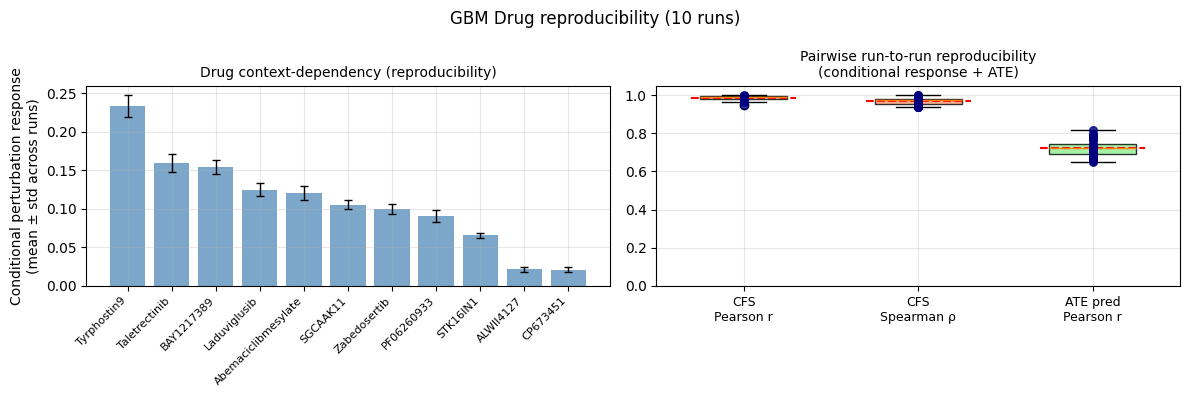

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: mean shift ± std
ax = axes[0]
ax.bar(range(len(df_shift)), df_shift['mean_shift'], color='steelblue', alpha=0.7)
ax.errorbar(range(len(df_shift)), df_shift['mean_shift'],
            yerr=df_shift['std_shift'], fmt='none', color='black', capsize=3, lw=1)
ax.set_xticks(range(len(df_shift)))
ax.set_xticklabels(df_shift['perturbation'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Conditional perturbation response\n(mean ± std across runs)')
ax.set_title('Drug context-dependency (reproducibility)', fontsize=10)
ax.grid(True, alpha=0.3)

# Boxplot of pairwise CFS correlations
ax = axes[1]
for pos, (vals, title, fc) in enumerate([
    (cfs_pearson,  'Pearson r',   'lightsteelblue'),
    (cfs_spearman, 'Spearman ρ',  'lightsalmon'),
    (ate_pred_corrs, 'ATE pred\nPearson r', 'lightgreen'),
], 1):
    clean = [v for v in vals if np.isfinite(v)]
    ax.boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=fc, alpha=0.8))
    ax.scatter([pos]*len(clean), clean, s=30, color='navy', zorder=3, alpha=0.8)
    m = np.mean(clean)
    ax.plot([pos-0.3, pos+0.3], [m, m], 'r--', lw=1.5, label=f'mean={m:.3f}')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['CFS\nPearson r', 'CFS\nSpearman ρ', 'ATE pred\nPearson r'], fontsize=9)
ax.set_title('Pairwise run-to-run reproducibility\n(conditional response + ATE)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

fig.suptitle(f'GBM Drug reproducibility ({N_RUNS} runs)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/cfs_ate_reproducibility.png', bbox_inches='tight', dpi=150)
plt.show()

## Part 7 — Perturbation-to-target bipartite reproducibility

The `counterfactual_effect_size` (shape P × G per condition) encodes the predicted
effect of each drug on each gene in each condition.  

We measure pairwise Pearson r of the full P×G matrices (flattened) across runs,
separately per condition.

In [16]:
cf_corrs_per_cond = {c: [] for c in cond_names}

for ci, cname in enumerate(cond_names):
    for i, j in pairs:
        xi = run_results[i]['cf_sizes'][ci].ravel()
        xj = run_results[j]['cf_sizes'][ci].ravel()
        v  = np.isfinite(xi) & np.isfinite(xj)
        cf_corrs_per_cond[cname].append(pearsonr(xi[v], xj[v])[0] if v.sum() > 2 else np.nan)

print('Perturbation-to-target CF effect size Pearson r (pairwise, per condition):')
for cname, vals in cf_corrs_per_cond.items():
    clean = [v for v in vals if np.isfinite(v)]
    print(f'  {cname}: {np.mean(clean):.4f} ± {np.std(clean):.4f}')

Perturbation-to-target CF effect size Pearson r (pairwise, per condition):
  NoT: 0.6404 ± 0.1717
  0.5T: 0.7444 ± 0.2341


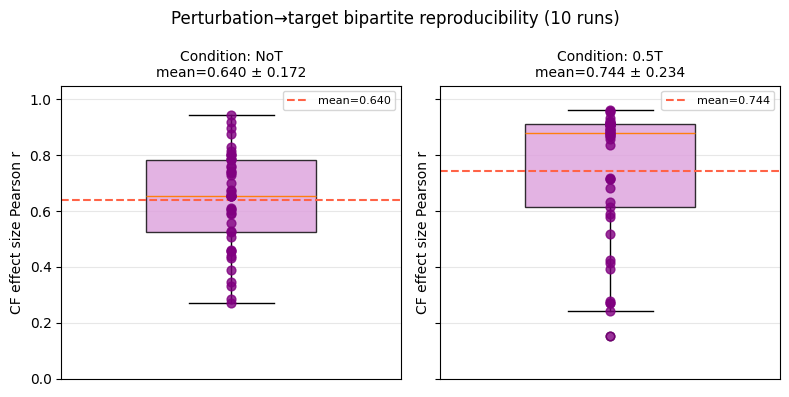

In [17]:
n_c = len(cond_names)
fig, axes = plt.subplots(1, n_c, figsize=(4 * n_c, 4), sharey=True)
if n_c == 1:
    axes = [axes]

for ax, cname in zip(axes, cond_names):
    vals  = cf_corrs_per_cond[cname]
    clean = [v for v in vals if np.isfinite(v)]
    ax.boxplot(clean, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='plum', alpha=0.8))
    ax.scatter([1]*len(clean), clean, s=40, color='purple', zorder=3, alpha=0.8)
    m = np.mean(clean)
    ax.axhline(m, color='tomato', lw=1.5, ls='--', label=f'mean={m:.3f}')
    ax.set_title(f'Condition: {cname}\nmean={m:.3f} ± {np.std(clean):.3f}', fontsize=10)
    ax.set_xticks([])
    ax.set_ylabel('CF effect size Pearson r')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Perturbation→target bipartite reproducibility ({N_RUNS} runs)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/cf_bipartite_reproducibility.png', bbox_inches='tight', dpi=150)
plt.show()

## Part 7b — ev_sig significant gene-set reproducibility

For each condition, compare the sets of significant (perturbation, gene) pairs
(q < 0.05) across runs using Jaccard similarity.  
This directly tests whether the bipartite graph findings are consistent.

## Part 8 — Summary: all metrics

Consolidated view of all pairwise reproducibility metrics.

In [18]:
metric_labels = (['W co-act.', 'rho', 'Jaccard (raw)', 'Jaccard (aln)',
                   'ATE pred'] +
                  [f'CF ({c})' for c in cond_names] +
                  ['CFS Pearson', 'CFS Spearman'])
metric_vals   = ([w_corrs, rho_corrs, jac_raw, jac_aln, ate_pred_corrs] +
                  [cf_corrs_per_cond[c] for c in cond_names] +
                  [cfs_pearson, cfs_spearman])

rows = []
for label, vals in zip(metric_labels, metric_vals):
    clean = [v for v in vals if np.isfinite(v)]
    rows.append({'metric': label, 'mean': np.mean(clean),
                 'std': np.std(clean), 'min': np.min(clean), 'max': np.max(clean)})
summary_df = pd.DataFrame(rows).set_index('metric')
print('Reproducibility summary (all pairwise run comparisons):')
print(summary_df.round(4).to_string())

Reproducibility summary (all pairwise run comparisons):
                 mean     std     min     max
metric                                       
W co-act.      0.8473  0.0623  0.7104  0.9448
rho            0.8473  0.0980  0.5330  0.9606
Jaccard (raw)  0.4699  0.1786  0.2414  1.0000
Jaccard (aln)  0.4699  0.1786  0.2414  1.0000
ATE pred       0.7242  0.0411  0.6503  0.8151
CF (NoT)       0.6404  0.1717  0.2718  0.9437
CF (0.5T)      0.7444  0.2341  0.1533  0.9633
CFS Pearson    0.9854  0.0109  0.9496  0.9981
CFS Spearman   0.9703  0.0177  0.9364  1.0000


In [19]:
# EV_ALPHA = 0.05

# evsig_jaccard_per_cond = {c: [] for c in cond_names}

# for ci, cname in enumerate(cond_names):
#     # Build set of significant (pert_idx, gene_idx) pairs per run
#     sig_sets = []
#     for rr in run_results:
#         qv   = rr['ev_qvals'][ci]      # (P, G)
#         idxs = set(zip(*np.where(qv < EV_ALPHA)))
#         sig_sets.append(idxs)

#     for i, j in pairs:
#         si, sj = sig_sets[i], sig_sets[j]
#         union  = si | sj
#         inter  = si & sj
#         jac    = len(inter) / len(union) if union else np.nan
#         evsig_jaccard_per_cond[cname].append(jac)

# print(f'ev_sig Jaccard (q<{EV_ALPHA}, significant pert×gene pairs) per condition:')
# for cname, vals in evsig_jaccard_per_cond.items():
#     clean = [v for v in vals if np.isfinite(v)]
#     print(f'  {cname}: {np.mean(clean):.4f} ± {np.std(clean):.4f}'
#           f'  (min={np.min(clean):.4f}  max={np.max(clean):.4f})')

# # Add ev_sig Jaccard to the metric lists for the summary boxplot
# for cname in cond_names:
#     label = f'ev_sig Jac ({cname})'
#     if label not in metric_labels:
#         metric_labels.append(label)
#         metric_vals.append(evsig_jaccard_per_cond[cname])

In [20]:
TOP_N = 50
G = data.n_vars

cf_topn_per_cond = {c: [] for c in cond_names}

for ci, cname in enumerate(cond_names):
    for i, j in pairs:
        ci_mat = run_results[i]['cf_sizes'][ci]
        cj_mat = run_results[j]['cf_sizes'][ci]

        row_jacs = []
        for p in range(ci_mat.shape[0]):
            top_i = set(np.argsort(-ci_mat[p])[:TOP_N])
            top_j = set(np.argsort(-cj_mat[p])[:TOP_N])
            inter = top_i & top_j
            union = top_i | top_j
            row_jacs.append(len(inter) / len(union))

        cf_topn_per_cond[cname].append(np.mean(row_jacs))

null = TOP_N / (2 * G - TOP_N)

print(f'Raw CF top-{TOP_N} Jaccard per condition (null = {null:.4f}, random chance with {G} genes):')
for cname, vals in cf_topn_per_cond.items():
    clean = [v for v in vals if np.isfinite(v)]
    mean = np.mean(clean)
    print(f'  {cname}: {mean:.4f} ± {np.std(clean):.4f}  ({mean/null:.1f}x above chance)')

# Add ev_sig Jaccard to the metric lists for the summary boxplot
for cname in cond_names:
    label = f'ev_sig top {TOP_N} Jac ({cname})'
    if label not in metric_labels:
        metric_labels.append(label)
        metric_vals.append(cf_topn_per_cond[cname])


Raw CF top-50 Jaccard per condition (null = 0.0087, random chance with 2894 genes):
  NoT: 0.3693 ± 0.0875  (42.4x above chance)
  0.5T: 0.2499 ± 0.0362  (28.7x above chance)


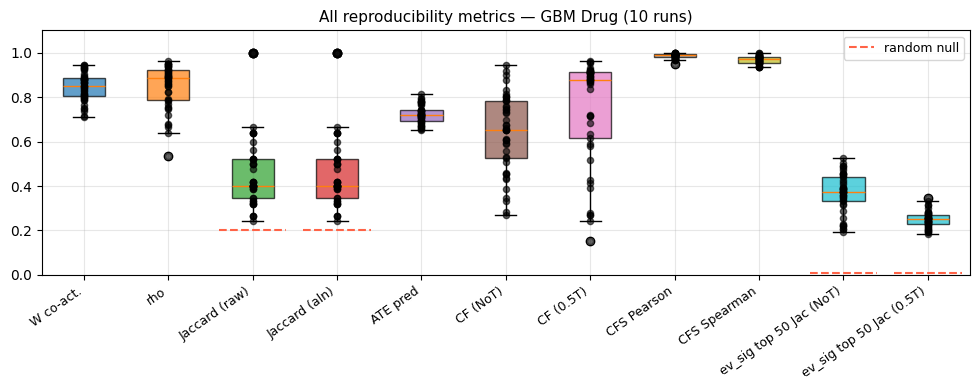

In [21]:
G = data.n_vars  # 2894

# null value per Jaccard-type label
jac_null_map = {}
for label in metric_labels:
    if label in ('Jaccard (raw)', 'Jaccard (aln)'):
        jac_null_map[label] = 1 / (2 * N_CLUSTERS - 1)          # 0.2 for K=3
    elif 'top' in label and '(' in label:                         # CF topN labels
        jac_null_map[label] = TOP_N / (2 * G - TOP_N)

n_m = len(metric_labels)
fig, ax = plt.subplots(figsize=(max(8, n_m * 0.9), 4))
colors = plt.cm.tab10(np.linspace(0, 1, n_m))

for pos, (label, vals, col) in enumerate(zip(metric_labels, metric_vals, colors), 1):
    clean = [v for v in vals if np.isfinite(v)]
    if not clean:
        continue
    ax.boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=col, alpha=0.7))
    ax.scatter([pos]*len(clean), clean, s=20, color='k', zorder=3, alpha=0.6)

    if label in jac_null_map:
        null_y = jac_null_map[label]
        ax.plot([pos - 0.4, pos + 0.4], [null_y, null_y],
                color='tomato', lw=1.5, ls='--', zorder=4)

# legend entry for the null line
ax.plot([], [], color='tomato', lw=1.5, ls='--', label='random null')
ax.legend(fontsize=9)

ax.set_xticks(range(1, n_m + 1))
ax.set_xticklabels(metric_labels, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title(f'All reproducibility metrics — GBM Drug ({N_RUNS} runs)', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/all_metrics_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()


## Part 9 — Best model: recapitulate key figures

Load the best-ATE model and regenerate the key figures from
`gbm_run_conditions_bt333_with_T_cell_conditions_figures_10um.ipynb`.

In [22]:
best_model = slk.tl.load_results(f'{RESULTS_DIR}/matrices/best_model.pth')

if hasattr(data.X, 'toarray'):
    data.X = data.X.toarray()

slk.tl.eval_single(best_model, data, obsm_key='z', uns_key='results', device=DEVICE)

best_run_loaded = int(np.loadtxt(f'{RESULTS_DIR}/matrices/best_run.txt'))
best_ate_r_val  = float(np.loadtxt(f'{RESULTS_DIR}/matrices/best_ate_r.txt'))
print(f'Loaded best model from run {best_run_loaded+1} (ATE r={best_ate_r_val:.4f})')

Loaded best model from run 9 (ATE r=0.6742)


/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


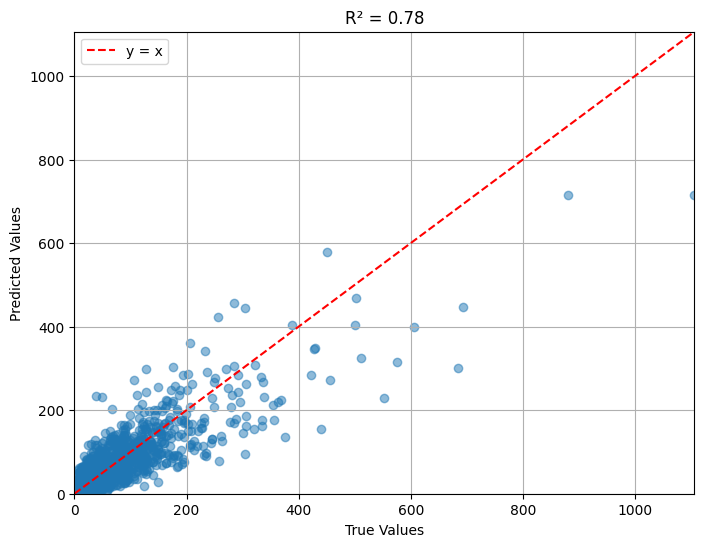

<Figure size 640x480 with 0 Axes>

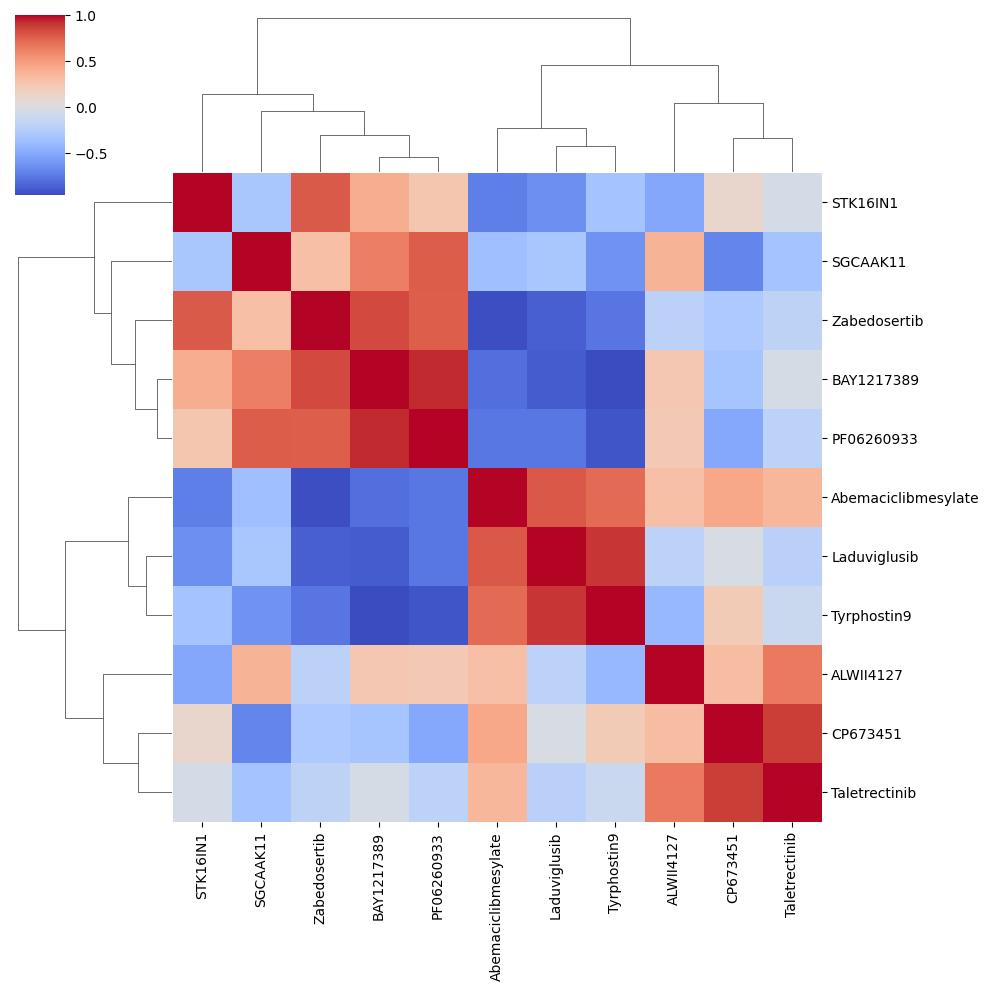

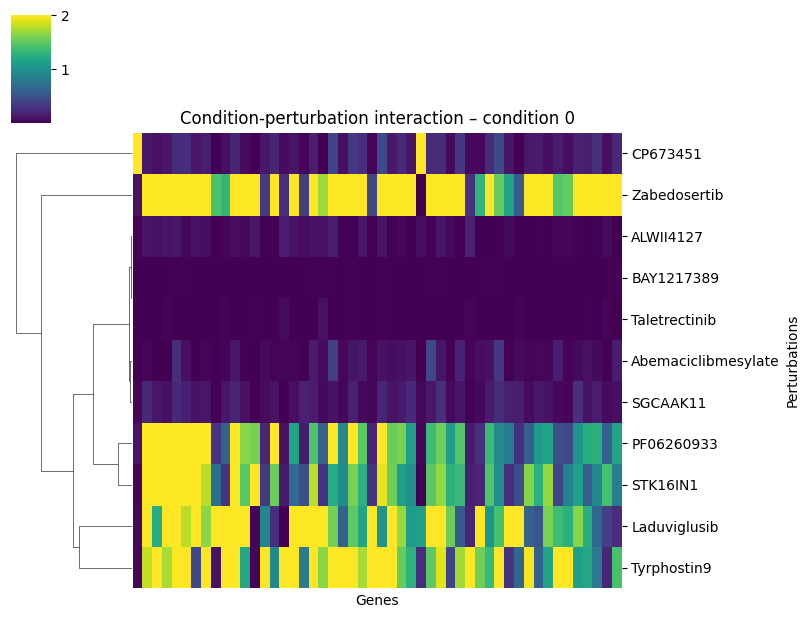

<Figure size 640x480 with 0 Axes>

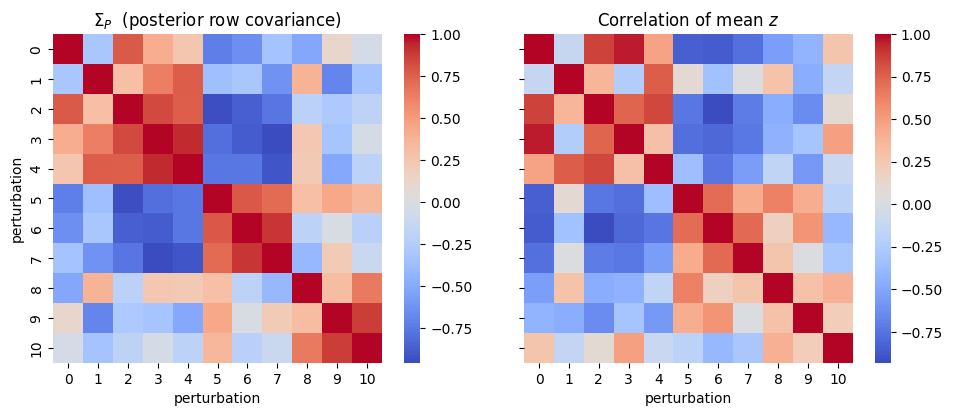

<Figure size 640x480 with 0 Axes>

In [23]:
# R², rho correlation, EV (eigenvalue ranking)
slk.pl.plot_r2(data)
plt.savefig(f'{RESULTS_DIR}/figures/best_r2.png', bbox_inches='tight', dpi=150)
plt.show()

slk.pl.plot_corr(data)
plt.savefig(f'{RESULTS_DIR}/figures/best_rho_corr.png', bbox_inches='tight', dpi=150)
plt.show()

slk.pl.plot_ev(data, cmax=2, top_n=50)
plt.savefig(f'{RESULTS_DIR}/figures/best_ev.png', bbox_inches='tight', dpi=150)
plt.show()

slk.pl.plot_zcorr(data)
plt.savefig(f'{RESULTS_DIR}/figures/best_zcorr.png', bbox_inches='tight', dpi=150)
plt.show()

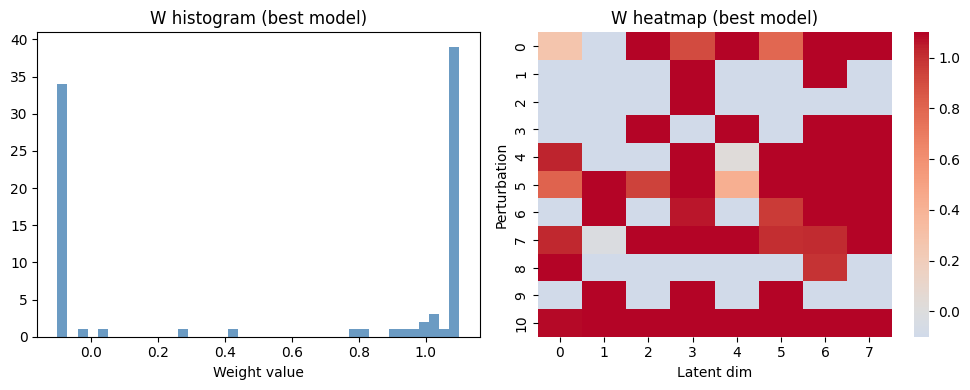

In [24]:
# W matrix
W_best = data.uns['results']['W']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(W_best.flatten(), bins=40, color='steelblue', alpha=0.8)
axes[0].set_title('W histogram (best model)')
axes[0].set_xlabel('Weight value')
sns.heatmap(W_best, ax=axes[1], cmap='coolwarm', center=0)
axes[1].set_title('W heatmap (best model)')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('Perturbation')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_W.png', bbox_inches='tight', dpi=150)
plt.show()

show=True is only supported for criterion='distance'. Ignoring.

Best model clustering (N_CLUSTERS=3):
  Group 1 (5): ['BAY1217389', 'PF06260933', 'SGCAAK11', 'STK16IN1', 'Zabedosertib']
  Group 2 (3): ['Abemaciclibmesylate', 'Laduviglusib', 'Tyrphostin9']
  Group 3 (3): ['ALWII4127', 'CP673451', 'Taletrectinib']


<Figure size 640x480 with 0 Axes>

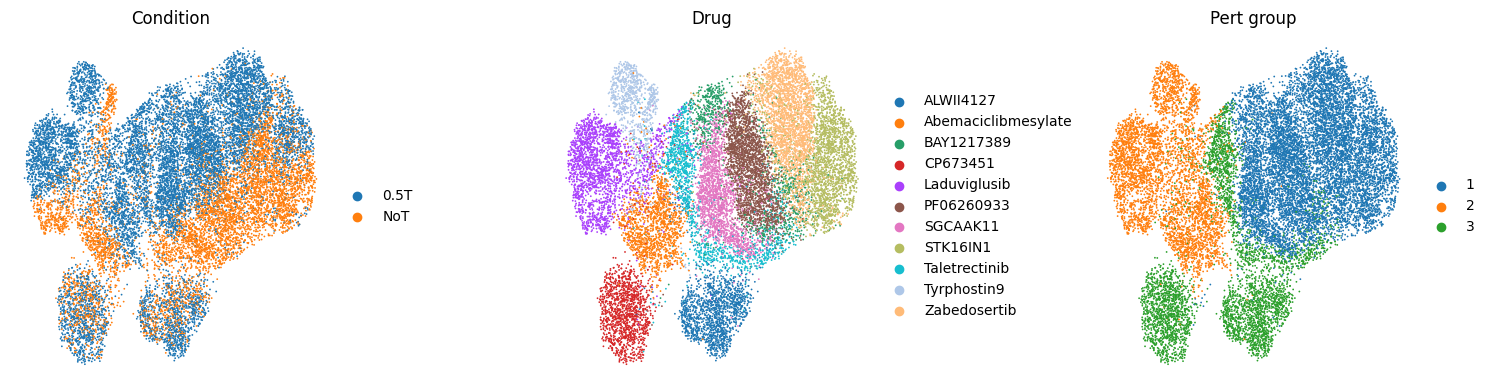

In [25]:
# Perturbation clustering + UMAP (best model)
groups       = slk.tl.cluster_rho(data, t=N_CLUSTERS, criterion='maxclust', show=True)
dataset      = slk.tl.PerturbMatchingDataset(data)
all_genes    = list(dataset.perturbation_dict.keys())
named_groups = slk.tl.group2name(groups, all_genes)

print(f'\nBest model clustering (N_CLUSTERS={N_CLUSTERS}):')
for g in sorted(named_groups['group'].unique()):
    members = sorted(named_groups[named_groups['group'] == g].index.tolist())
    print(f'  Group {g} ({len(members)}): {members}')

plt.savefig(f'{RESULTS_DIR}/figures/best_dendrogram_k{N_CLUSTERS}.png', bbox_inches='tight', dpi=150)
plt.show()

# UMAP of latent z-space coloured by drug, condition, and cluster group
sub = data[data.obs[p_key] != NTC].copy()
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z', random_state=0)
sc.tl.umap(sub, random_state=0)

gene_to_group = named_groups['group'].to_dict()
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group).fillna(-1).astype('category')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.umap(sub, color=c_key,        frameon=False, ax=axes[0], show=False, title='Condition')
sc.pl.umap(sub, color=p_key,        frameon=False, ax=axes[1], show=False, title='Drug', legend_loc='right margin')
sc.pl.umap(sub, color='pert_group', frameon=False, ax=axes[2], show=False, title='Pert group')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_umap.png', bbox_inches='tight', dpi=150)
plt.show()

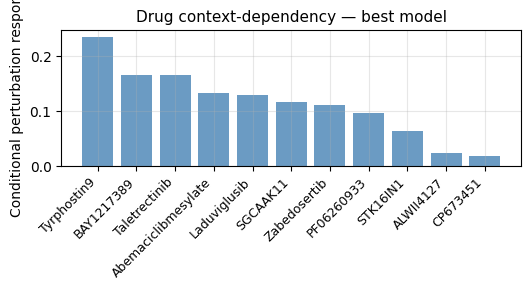

In [26]:
# Conditional perturbational response (CFS bar chart) — best model
res       = data.uns['results']
pert_names = list(res['rho_perts'])
cfs_best   = np.asarray(res['condition_perturbation_interaction'], dtype=float)
cond_best  = list(res['conditions'])

n_c       = len(cond_best)
mask_c    = np.triu(np.ones((n_c, n_c)), k=1).astype(bool)
avg_shift = np.array([cfs_best[p][mask_c].mean() for p in range(len(pert_names))])

df_sens = pd.DataFrame({
    'perturbation': pert_names,
    'condition_effect': avg_shift,
}).sort_values('condition_effect', ascending=False)

fig, ax = plt.subplots(figsize=(max(4, len(pert_names) * 0.5), 3))
ax.bar(range(len(df_sens)), df_sens['condition_effect'], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(df_sens)))
ax.set_xticklabels(df_sens['perturbation'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Conditional perturbation response')
ax.set_title('Drug context-dependency — best model', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_cfs_bar.png', bbox_inches='tight', dpi=150)
plt.show()

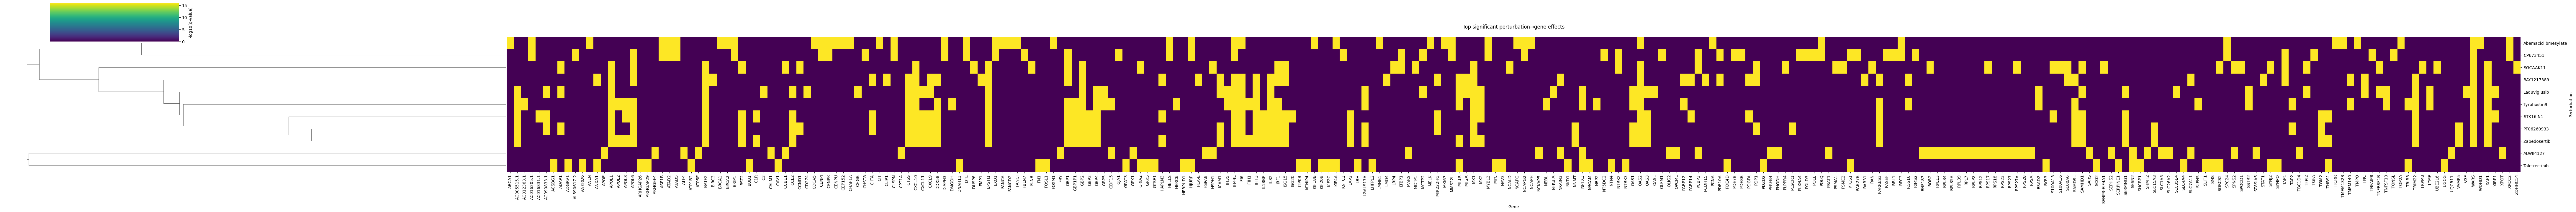

<Figure size 640x480 with 0 Axes>

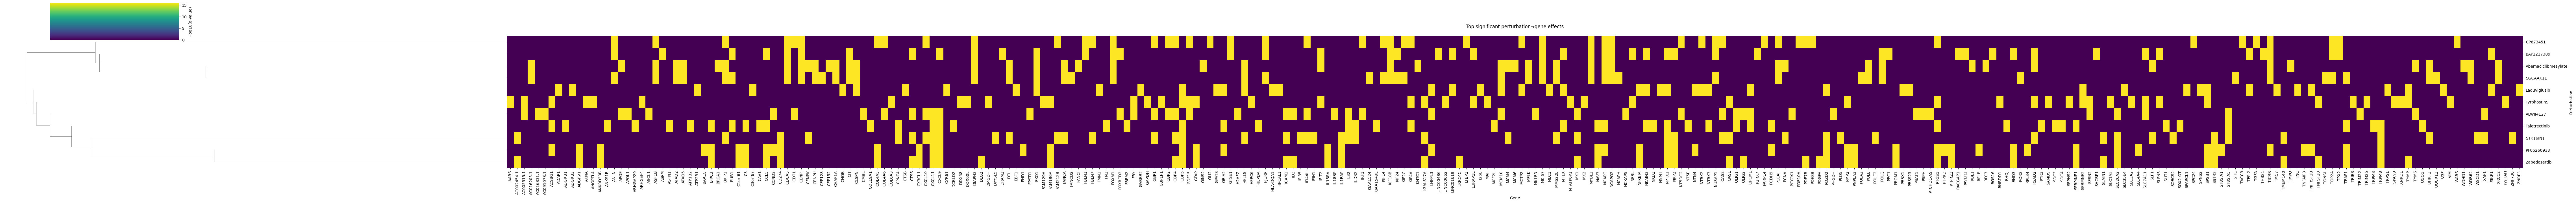

<Figure size 640x480 with 0 Axes>

In [27]:
# EV significance heatmap per condition
cond_labels_best = data.uns['results']['conditions']
for cond_idx, cond_label in enumerate(cond_labels_best):
    slk.tl.ev_sig(data, cond_idx=cond_idx)
    try:
        slk.pl.plot_ev_sig(
            data, cond_idx=cond_idx, uns_key='results',
            alpha=0.05, top_n_genes=50, min_sig_genes=3,
            cluster_rows=True, cluster_cols=False,
        )
        plt.savefig(f'{RESULTS_DIR}/figures/best_ev_sig_{cond_label}.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
    except Exception as e:
        print(f'  Condition {cond_label}: {e}')

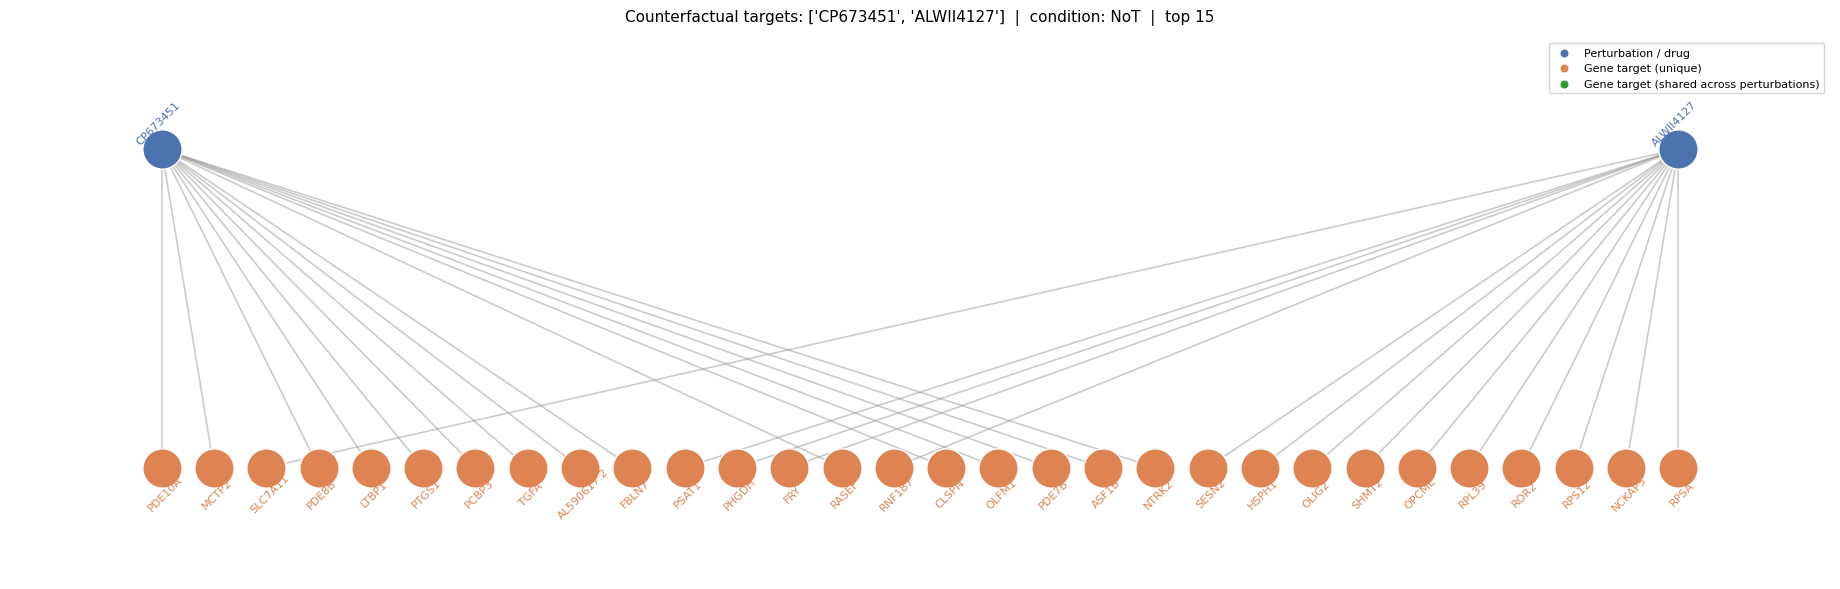

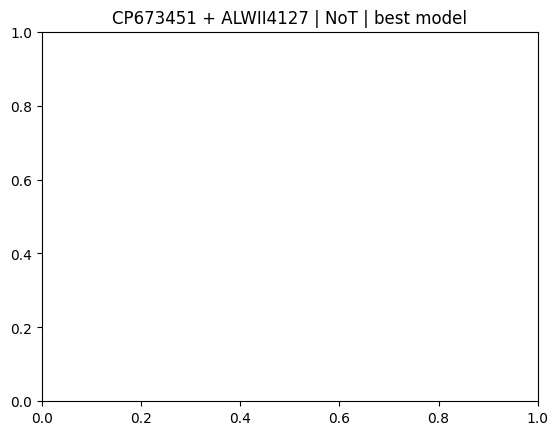

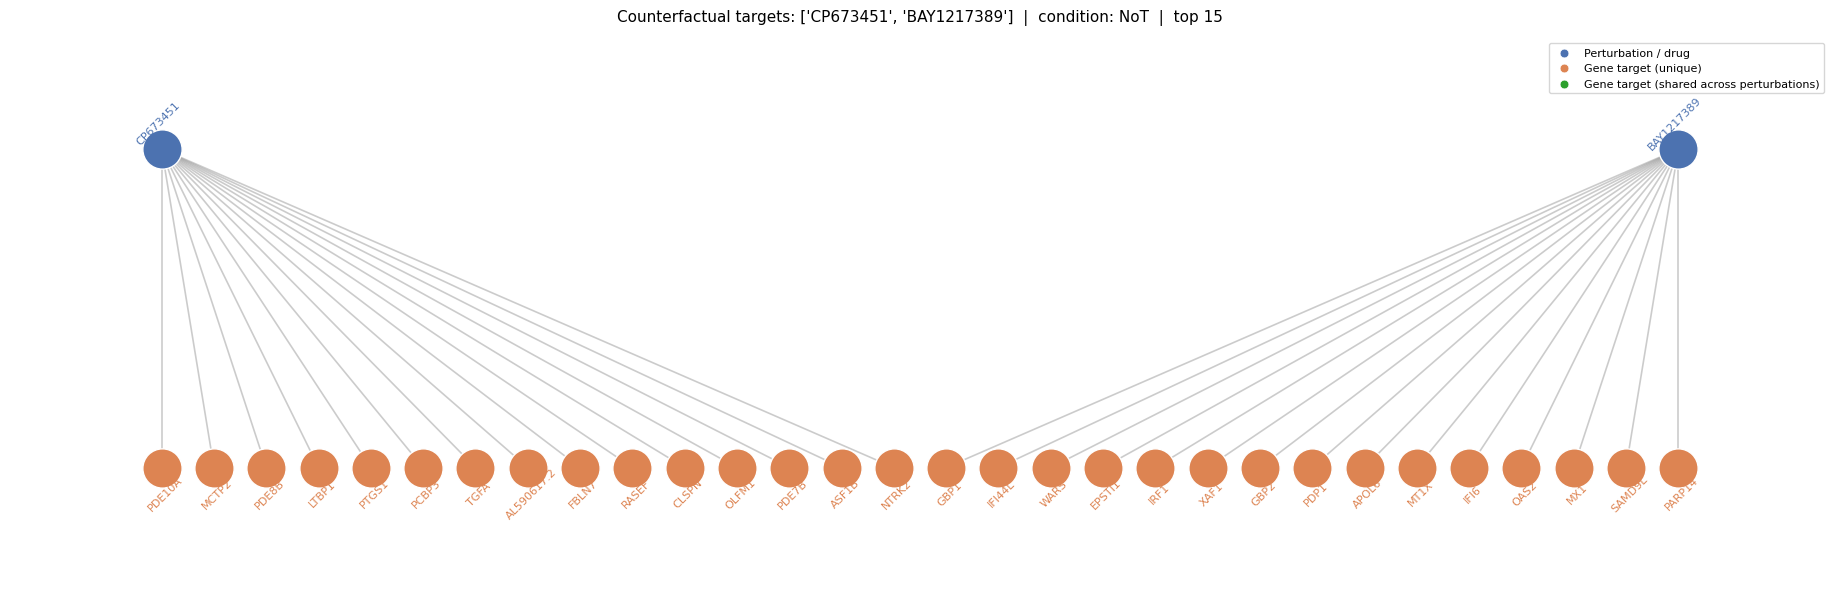

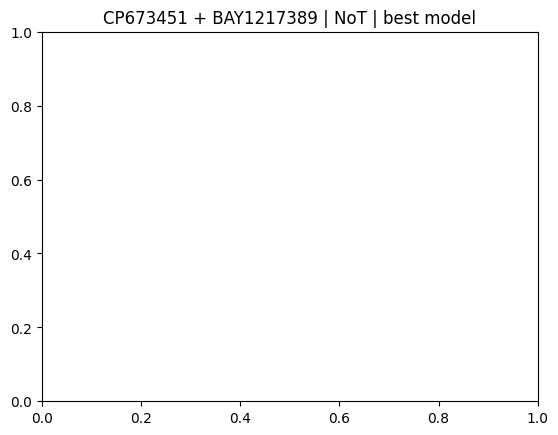

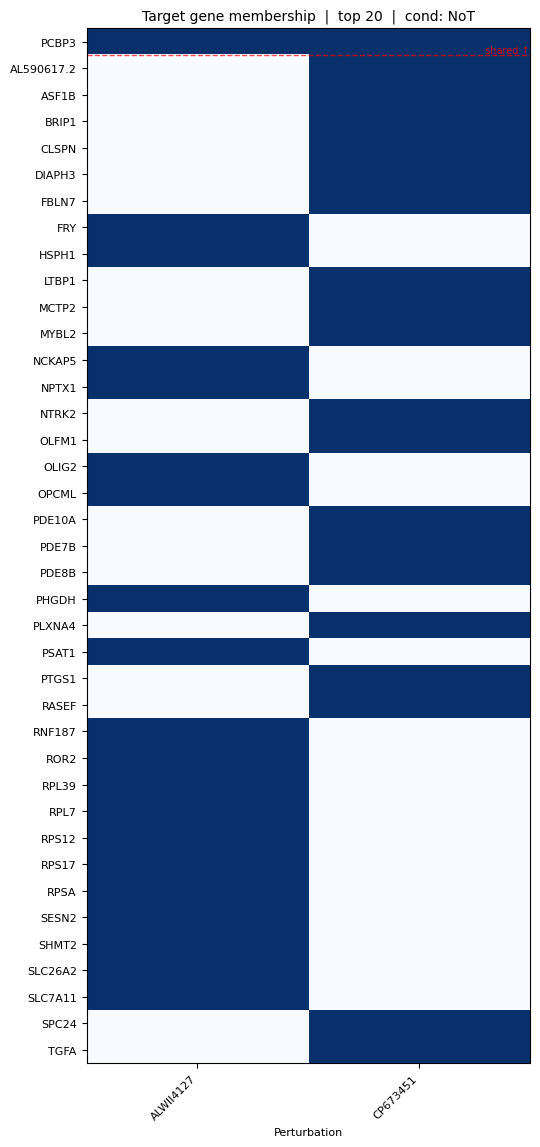

<Figure size 640x480 with 0 Axes>

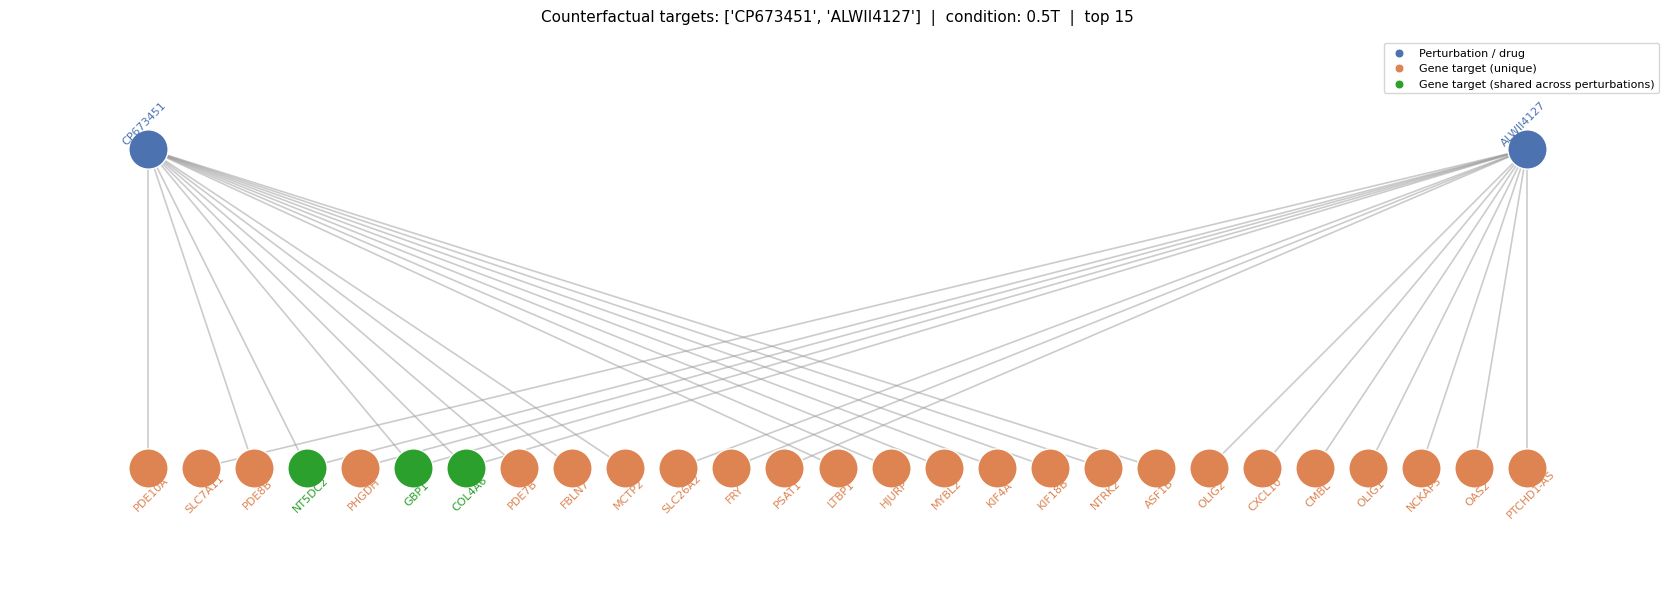

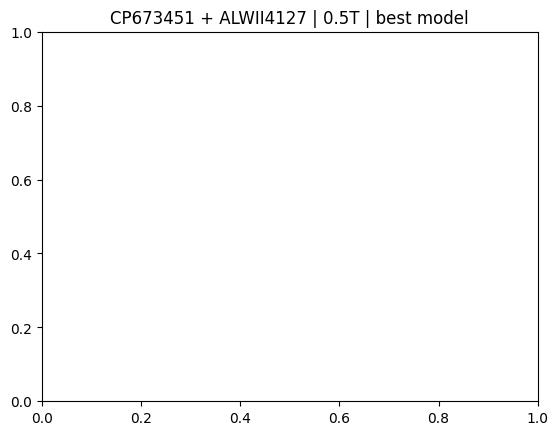

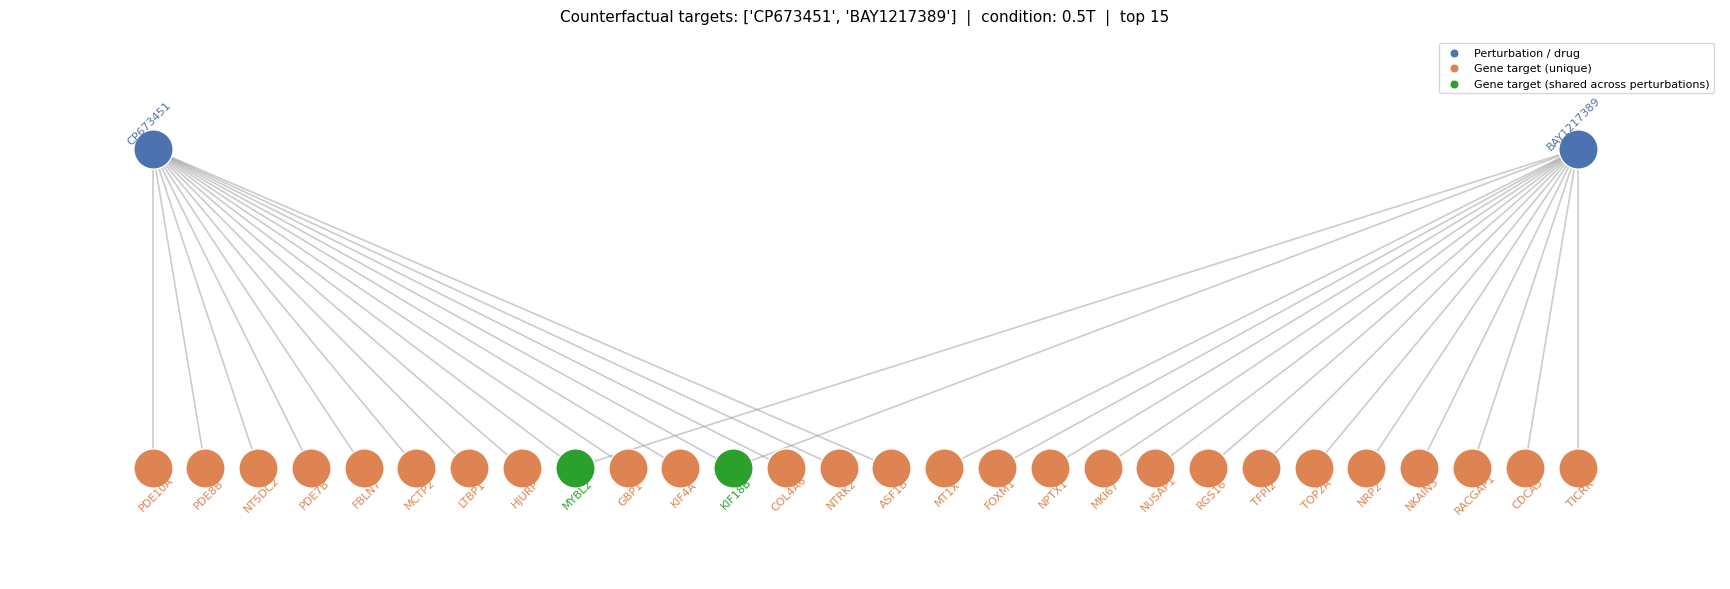

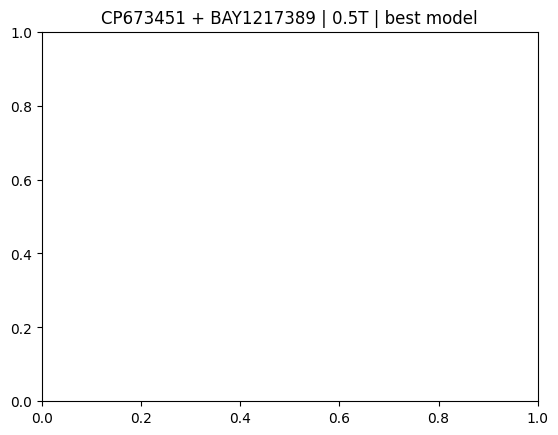

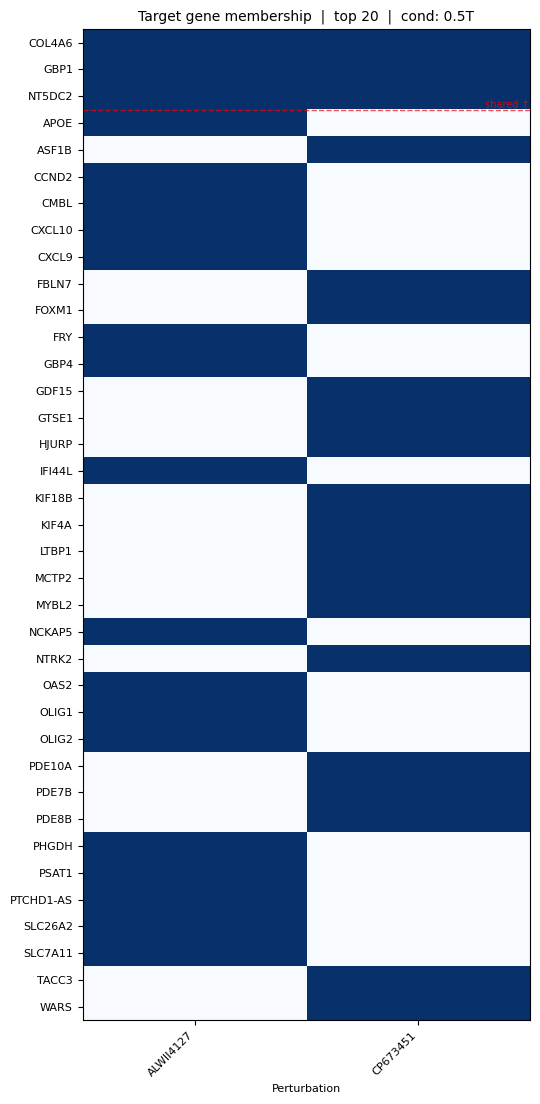

<Figure size 640x480 with 0 Axes>

In [28]:
# Perturbation → target bipartite graphs per condition
# Individual drugs + joint pairs matching the original notebook
cond_labels_best = data.uns['results']['conditions']

for cond_idx, cond_label in enumerate(cond_labels_best):
    # Joint: CP673451 + ALWII4127 (matches original fig cell 65)
    slk.pl.plot_cf_bipartite(
        data, cond_idx=cond_idx,
        pert_name=['CP673451', 'ALWII4127'], top_n=15,
    )
    plt.title(f'CP673451 + ALWII4127 | {cond_label} | best model')
    plt.savefig(f'{RESULTS_DIR}/figures/best_bipartite_CP_AL_{cond_label}.png',
                bbox_inches='tight', dpi=150)
    plt.show()

    # Joint: CP673451 + BAY1217389 (matches original fig cell 66)
    try:
        slk.pl.plot_cf_bipartite(
            data, cond_idx=cond_idx,
            pert_name=['CP673451', 'BAY1217389'], top_n=15,
        )
        plt.title(f'CP673451 + BAY1217389 | {cond_label} | best model')
        plt.savefig(f'{RESULTS_DIR}/figures/best_bipartite_CP_BAY_{cond_label}.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
    except Exception as e:
        print(f'  BAY1217389 / {cond_label}: {e}')

    # Target overlap (gene × drug membership matrix) — matches original cells 69/70
    slk.pl.plot_cf_target_overlap(
        data, cond_idx=cond_idx, top_n=20,
        pert_names=['CP673451', 'ALWII4127'],
        show_jaccard=False, show_membership=True,
    )
    plt.savefig(f'{RESULTS_DIR}/figures/best_cf_target_overlap_{cond_label}.png',
                bbox_inches='tight', dpi=150)
    plt.show()

In [29]:
# Shared significant gene analysis per condition (matches original notebook cell 32)
# Genes significantly regulated by BOTH ALWII4127 and CP673451
alpha = 0.05
cond_labels_best = data.uns['results']['conditions']

for cond_idx, cond_label in enumerate(cond_labels_best):
    slk.tl.ev_sig(data, cond_idx=cond_idx)
    df_ev     = slk.pl.make_ev_long_df(data, cond_idx=cond_idx, uns_key='results')
    df_ev_sig = df_ev[df_ev['qval'] < alpha]

    genes_AL = set(df_ev_sig[df_ev_sig['pert'] == 'ALWII4127']['gene'])
    genes_CP = set(df_ev_sig[df_ev_sig['pert'] == 'CP673451']['gene'])
    shared   = genes_AL & genes_CP

    print(f'\nCondition: {cond_label}')
    print(f'  Sig genes ALWII4127 : {len(genes_AL)}')
    print(f'  Sig genes CP673451  : {len(genes_CP)}')
    print(f'  Shared genes        : {len(shared)}')

    if shared:
        df_shared = (
            df_ev_sig[df_ev_sig['gene'].isin(shared) &
                      df_ev_sig['pert'].isin(['ALWII4127', 'CP673451'])]
            [['pert', 'gene', 'ev', 'qval']]
            .pivot(index='gene', columns='pert', values=['ev', 'qval'])
            .sort_values(('ev', 'ALWII4127'), ascending=False)
        )
        df_shared.columns = ['ev_AL', 'ev_CP', 'qval_AL', 'qval_CP']
        print(df_shared.round(4).to_string())


Condition: NoT
  Sig genes ALWII4127 : 607
  Sig genes CP673451  : 611
  Shared genes        : 229
              ev_AL   ev_CP  qval_AL  qval_CP
gene                                         
SLC7A11      2.0274  0.2732   0.0000   0.0000
FRY          0.7261  0.0536   0.0000   0.0432
RNF187       0.5486  0.0927   0.0000   0.0000
SESN2        0.5006  0.0821   0.0000   0.0002
HSPH1        0.4110  0.0843   0.0000   0.0001
OPCML        0.3403  0.1776   0.0000   0.0000
ROR2         0.3191  0.2525   0.0000   0.0000
RPS12        0.3161  0.1631   0.0000   0.0000
NCKAP5       0.3155  0.1711   0.0000   0.0000
RPSA         0.2994  0.0714   0.0000   0.0022
PCBP3        0.2966  1.0036   0.0000   0.0000
RPL7         0.2940  0.1131   0.0000   0.0000
RPS17        0.2938  0.1049   0.0000   0.0000
SEPHS2       0.2658  0.1986   0.0000   0.0000
RPS27        0.2634  0.1527   0.0000   0.0000
RPS27A       0.2615  0.1322   0.0000   0.0000
MARS         0.2614  0.0900   0.0000   0.0000
SPNS2        0.2527  0.121

## Part 10 — UMAP (best model, publication style)

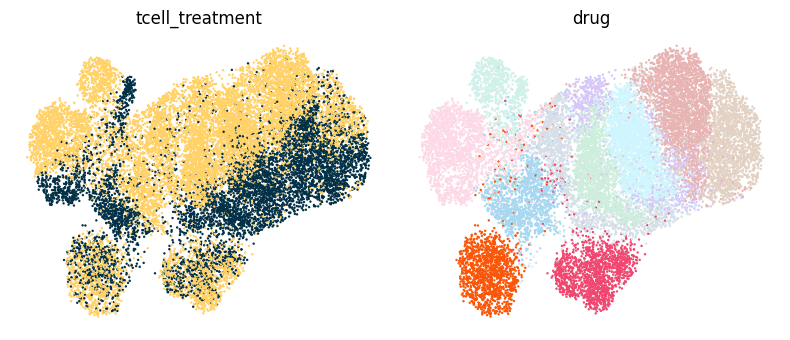

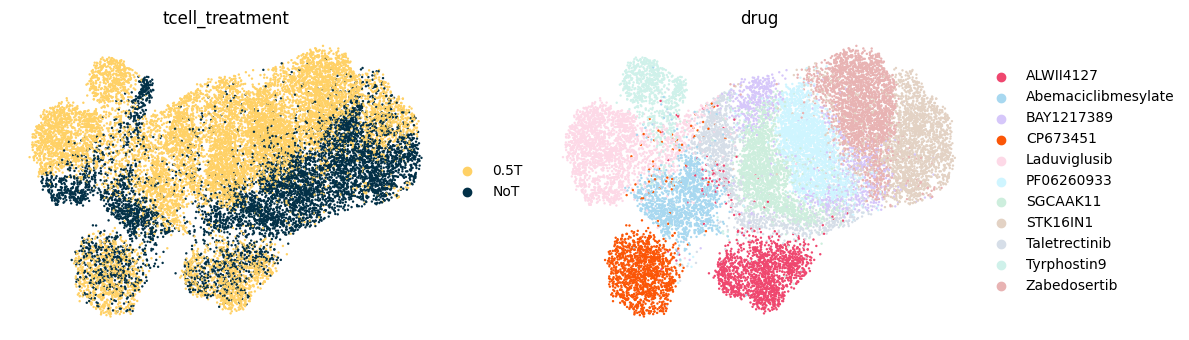

In [30]:
import random

palette1 = ["#FFD166", "#023047"]

palette2_very_light = [
    "#EF476F",  # keep
    "#A8D8F0",  # very light blue
    "#D6C7FA",  # very light purple
    "#FB5607",  # keep
    "#FDD9E7",  # very light pink
    "#CFF5FF",  # very light cyan
    "#CDEEDD",  # very light green
    "#E3D2C4",  # very light brown
    "#D6DEE8",  # very light gray-blue
    "#CFF1EA",  # very light teal
    "#E8B3B3",  # very light dark red
]

# Recompute sub/UMAP from best model z-space (in case this cell is run standalone)
sub = data[data.obs[p_key] != NTC].copy()
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z', random_state=0)
sc.tl.umap(sub, random_state=0)

# ── compact, no legends ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
sc.pl.umap(sub, color=c_key, title=c_key,
           palette=palette1,          size=12, frameon=False,
           ax=axes[0], show=False, legend_loc=None)
sc.pl.umap(sub, color=p_key, title=p_key,
           palette=palette2_very_light, size=12, frameon=False,
           ax=axes[1], show=False, legend_loc=None)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_umap_zspace.png',        bbox_inches='tight', dpi=300)
plt.savefig(f'{RESULTS_DIR}/figures/best_umap_zspace.svg',        bbox_inches='tight', dpi=300)
plt.show()

# ── with legends ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sc.pl.umap(sub, color=c_key, title=c_key,
           palette=palette1,          size=12, frameon=False,
           ax=axes[0], show=False)
sc.pl.umap(sub, color=p_key, title=p_key,
           palette=palette2_very_light, size=12, frameon=False,
           ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_umap_zspace_with_legends.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{RESULTS_DIR}/figures/best_umap_zspace_with_legends.svg', bbox_inches='tight', dpi=300)
plt.show()

counterfactual_effect_size shape: (2, 11, 2894)  (C=2, P=11, G=2894)
AL=ALWII4127 index=0   CP=CP673451 index=3
Conditions: ['NoT', '0.5T']

Condition: NoT
  Pearson  r = 0.022  (p = 2.27e-01)
  Spearman r = 0.226  (p = 7.86e-35)

Condition: 0.5T
  Pearson  r = 0.084  (p = 5.80e-06)
  Spearman r = 0.392  (p = 3.58e-107)



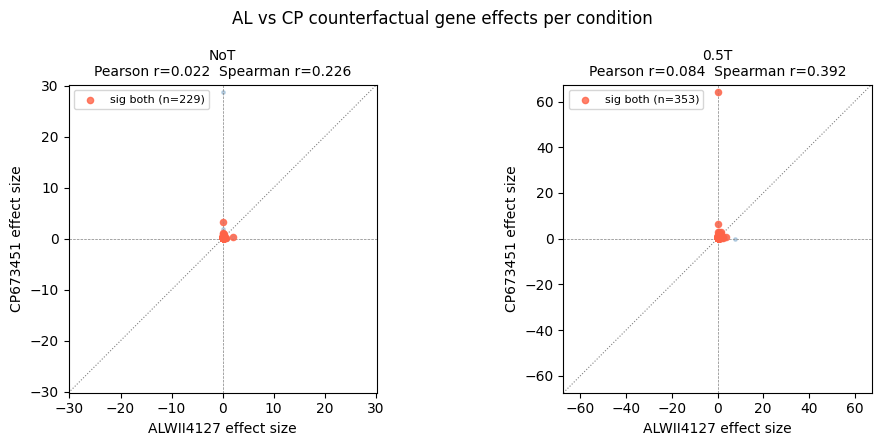

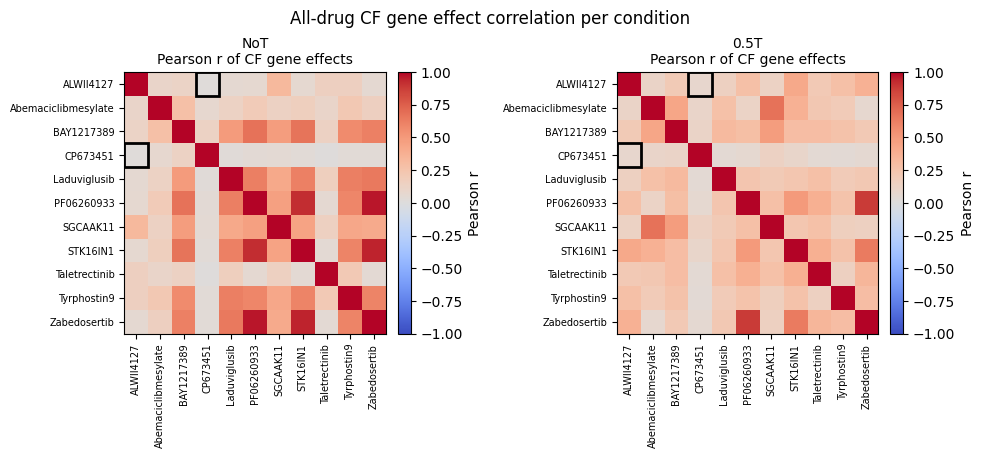

In [32]:
# ── AL vs CP cross-condition target gene correlation ────────────────────────
from scipy.stats import pearsonr, spearmanr

AL, CP      = 'ALWII4127', 'CP673451'
_ntc_labels = {'control', 'ctrl', 'non-targeting', 'dmso', 'vehicle'}

# counterfactual_effect_size shape: (C, P, G)
cfs      = np.asarray(data.uns['results']['counterfactual_effect_size'], dtype=float)
cond_names = list(data.uns['results']['conditions'])

# pert_names in model order (sorted, NTC removed)
_pnames = [p for p in np.unique(data.obs[slk.configs.get_config('pert_key')].values)
           if p.lower() not in _ntc_labels]
al_idx = _pnames.index(AL)
cp_idx = _pnames.index(CP)

print(f"counterfactual_effect_size shape: {cfs.shape}  (C={cfs.shape[0]}, P={cfs.shape[1]}, G={cfs.shape[2]})")
print(f"AL={AL} index={al_idx}   CP={CP} index={cp_idx}")
print(f"Conditions: {cond_names}\n")

# ── Per-condition Pearson/Spearman between AL and CP gene effect vectors ──
n_conds = len(cond_names)
fig, axes = plt.subplots(1, n_conds, figsize=(5 * n_conds, 4.5))
if n_conds == 1:
    axes = [axes]

for ci, (ax, cname) in enumerate(zip(axes, cond_names)):
    al_vec = cfs[ci, al_idx, :]   # (G,)
    cp_vec = cfs[ci, cp_idx, :]   # (G,)

    valid = np.isfinite(al_vec) & np.isfinite(cp_vec)
    r_p, p_p = pearsonr(al_vec[valid],  cp_vec[valid])
    r_s, p_s = spearmanr(al_vec[valid], cp_vec[valid])
    print(f"Condition: {cname}")
    print(f"  Pearson  r = {r_p:.3f}  (p = {p_p:.2e})")
    print(f"  Spearman r = {r_s:.3f}  (p = {p_s:.2e})\n")

    # scatter: one dot per gene
    ax.scatter(al_vec[valid], cp_vec[valid], s=6, alpha=0.3, color='steelblue', rasterized=True)

    # highlight genes significant for both (q < 0.05 in both AL and CP)
    if 'ev_results' in data.uns['results']:
        ev = data.uns['results']['ev_results']
        if ci < len(ev):
            qv = np.asarray(ev[ci]['qvals'], dtype=float)   # (P, G)
            both_sig = (qv[al_idx] < 0.05) & (qv[cp_idx] < 0.05) & valid
            ax.scatter(al_vec[both_sig], cp_vec[both_sig], s=20, alpha=0.8,
                       color='tomato', zorder=3, label=f'sig both (n={both_sig.sum()})')
            ax.legend(fontsize=8)

    # diagonal reference
    lim = max(np.abs(al_vec[valid]).max(), np.abs(cp_vec[valid]).max()) * 1.05
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.plot([-lim, lim], [-lim, lim], color='gray', lw=0.8, ls=':')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'{AL} effect size', fontsize=10)
    ax.set_ylabel(f'{CP} effect size', fontsize=10)
    ax.set_title(f'{cname}\nPearson r={r_p:.3f}  Spearman r={r_s:.3f}', fontsize=10)
    ax.set_aspect('equal')

plt.suptitle('AL vs CP counterfactual gene effects per condition', fontsize=12)
plt.tight_layout()
plt.show()

# ── Heatmap: all drug-pair Pearson r per condition ────────────────────────
fig, axes = plt.subplots(1, n_conds, figsize=(5 * n_conds, 4.5))
if n_conds == 1:
    axes = [axes]

for ci, (ax, cname) in enumerate(zip(axes, cond_names)):
    P = len(_pnames)
    r_mat = np.full((P, P), np.nan)
    for pi in range(P):
        for pj in range(pi, P):
            vi = cfs[ci, pi, :]
            vj = cfs[ci, pj, :]
            v  = np.isfinite(vi) & np.isfinite(vj)
            if v.sum() > 2:
                r, _ = pearsonr(vi[v], vj[v])
                r_mat[pi, pj] = r_mat[pj, pi] = r
    np.fill_diagonal(r_mat, 1.0)

    im = ax.imshow(r_mat, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(P)); ax.set_xticklabels(_pnames, rotation=90, fontsize=7)
    ax.set_yticks(range(P)); ax.set_yticklabels(_pnames, fontsize=7)
    ax.set_title(f'{cname}\nPearson r of CF gene effects', fontsize=10)
    plt.colorbar(im, ax=ax, label='Pearson r', fraction=0.046, pad=0.04)
    # highlight AL-CP cell
    ax.add_patch(plt.Rectangle((cp_idx - 0.5, al_idx - 0.5), 1, 1,
                                fill=False, edgecolor='black', lw=2))
    ax.add_patch(plt.Rectangle((al_idx - 0.5, cp_idx - 0.5), 1, 1,
                                fill=False, edgecolor='black', lw=2))

plt.suptitle('All-drug CF gene effect correlation per condition', fontsize=12)
plt.tight_layout()
plt.show()

Plotting condition 0: NoT


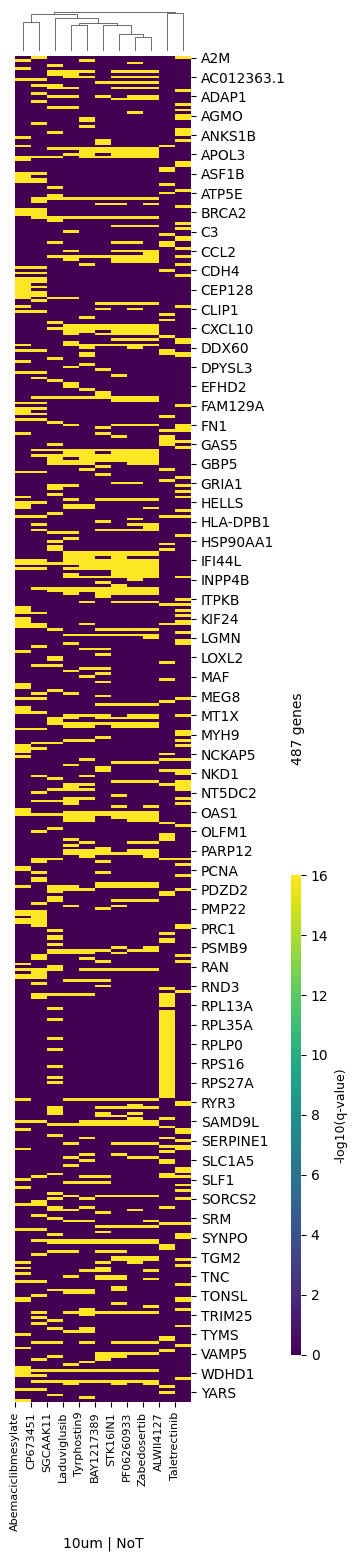

Plotting condition 1: 0.5T


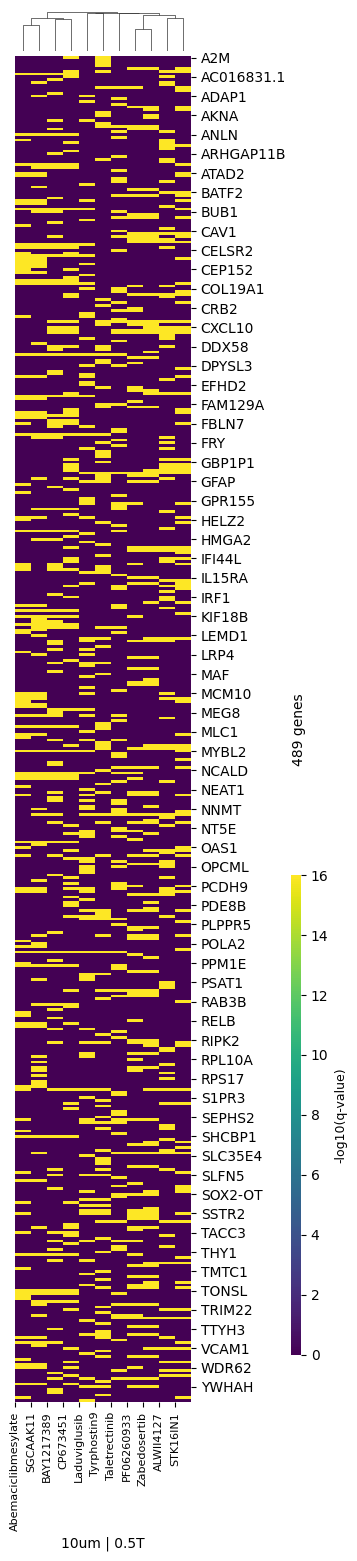

In [39]:
# --- Publication-ready wrapper: all conditions ---
# figure_dir is defined in cell 1
FIGSIZE = (2, 16)
DENDRO_RATIO = 0.03
concentration = 10

from unittest.mock import patch

cond_labels = data.uns['results']['conditions']
n_conds = len(data.uns['results']['counterfactual_effect_size'])

_orig_clustermap = sns.clustermap

def _make_patched(captured):
    def _patched_clustermap(*args, **kwargs):
        data_T = args[0].T
        args = (data_T,) + args[1:]
        row_cluster = kwargs.pop('row_cluster', True)
        col_cluster = kwargs.pop('col_cluster', False)
        kwargs['row_cluster'] = col_cluster
        kwargs['col_cluster'] = row_cluster
        kwargs['figsize'] = FIGSIZE
        kwargs['dendrogram_ratio'] = (0.1, DENDRO_RATIO)
        kwargs['cmap'] = 'viridis'
        kwargs['linewidths'] = 0
        kwargs['cbar_pos'] = (1.38, 0.15, 0.05, 0.3)
        g = _orig_clustermap(*args, **kwargs)
        captured['g'] = g
        return g
    return _patched_clustermap

for cond_idx in range(n_conds):
    cond_label = cond_labels[cond_idx]
    print(f'Plotting condition {cond_idx}: {cond_label}')
    _captured = {}
    with patch.object(sns, 'clustermap', _make_patched(_captured)):
        with patch.object(plt, 'show', lambda: None):
            slk.pl.plot_ev_sig(
                data,
                cond_idx=cond_idx,
                uns_key='results',
                alpha=0.05,
                top_n_genes=100,
                min_sig_genes=3,
                cluster_rows=True,
                cluster_cols=False,
                use_clustermap=True,
                cluster_by_raw=True
            )
    if 'g' not in _captured:
        print(f'  -> No significant results, skipping.')
        continue
    g = _captured['g']
    n_genes = g.data2d.shape[0]
    g.ax_heatmap.set_title('')
    g.ax_heatmap.set_xticks(range(g.data2d.shape[1]))
    g.ax_heatmap.set_xticklabels(list(g.data2d.columns), fontsize=8, rotation=90)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=10, rotation=0)
    g.ax_heatmap.set_xlabel(f'{concentration}um | {cond_label}', fontsize=10)
    g.ax_heatmap.set_ylabel(f'{n_genes} genes', fontsize=10)
    g.cax.set_ylabel('-log10(q-value)', fontsize=9)
    pos = g.ax_heatmap.get_position()
    new_x0 = 0.0
    new_width = 0.88
    g.ax_heatmap.set_position([new_x0, pos.y0, new_width, pos.height])
    dcol = g.ax_col_dendrogram.get_position()
    g.ax_col_dendrogram.set_position([new_x0, dcol.y0, new_width, dcol.height])
    plt.show()


  cond 0: 6443/31834 (pert,gene) pairs pass qval<0.05


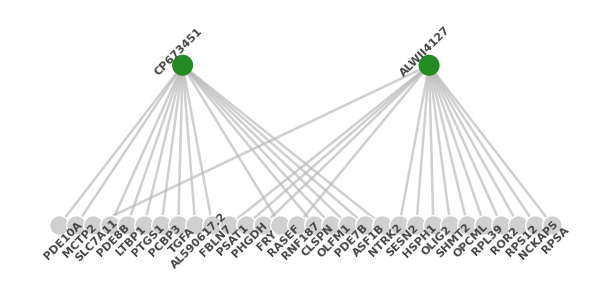

  cond 1: 6707/31834 (pert,gene) pairs pass qval<0.05


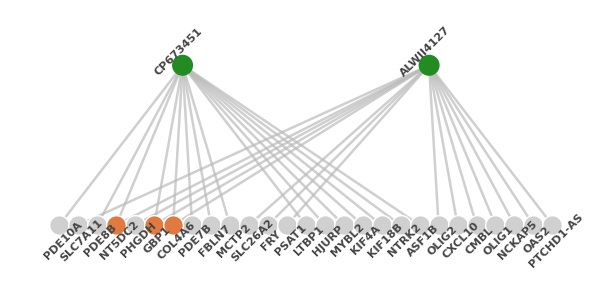

In [37]:
from scipy.cluster.hierarchy import linkage, leaves_list


new_colormap = [
    'darkslateblue',  # 0
    'firebrick',      # 1
    'darkorange',     # 2
    'forestgreen',    # 3
    'gold',           # 4
    'dodgerblue',     # 5
    'mediumorchid',   # 6
    'deeppink',       # 7
    'teal',           # 8
    'black'           # 9
]

# --- Publication-ready save for plot_cf_bipartite (figure_1 style) — all conditions ---
from matplotlib.collections import LineCollection
from unittest.mock import patch
import sherlock.plotting._simple as _slk_simple

PERT_X_MARGIN = 0.25  # 0=full spread, 0.5=fully centered
_orig_draw_bipartite = _slk_simple._draw_bipartite_nx

def _centered_draw_bipartite(pert_nodes, gene_nodes, edges, ax, **kwargs):
    n_p, n_g = len(pert_nodes), len(gene_nodes)
    if n_p == 1:
        orig_pert_xs = [0.5]
        new_pert_xs  = [0.5]
    else:
        orig_pert_xs = [i / (n_p - 1) for i in range(n_p)]
        new_pert_xs  = [PERT_X_MARGIN + i * (1 - 2*PERT_X_MARGIN) / (n_p - 1) for i in range(n_p)]
    x_remap = dict(zip(orig_pert_xs, new_pert_xs))
    _orig_draw_bipartite(pert_nodes, gene_nodes, edges, ax,
                         pert_color='#26547c',
                         gene_color='#D0D0D0',
                         gene_overlap_color='#E07A40',
                         **kwargs)
    for coll in ax.collections:
        offsets = coll.get_offsets()
        if offsets is None or len(offsets) == 0:
            continue
        if np.all(offsets[:, 1] == 1.0) and len(offsets) == n_p:
            coll.set_offsets(np.column_stack([new_pert_xs, np.ones(n_p)]))
    for txt, x in zip(ax.texts[:n_p], new_pert_xs):
        _, old_y = txt.get_position()
        txt.set_position((x, old_y))
    for coll in ax.collections:
        if not isinstance(coll, LineCollection):
            continue
        segs = coll.get_segments()
        new_segs = []
        for seg in segs:
            new_seg = []
            for pt in seg:
                x, y = pt
                if y == 1.0:
                    closest = min(orig_pert_xs, key=lambda ox: abs(ox - x))
                    x = x_remap.get(closest, x)
                new_seg.append([x, y])
            new_segs.append(new_seg)
        coll.set_segments(new_segs)

# Build pert→group color mapping (same clustering as plot_zcorr_colored)
from scipy.cluster.hierarchy import fcluster, set_link_color_palette, dendrogram
from matplotlib.colors import to_hex
_rho = data.uns['results']['rho_corr']
_pnames = data.uns['results']['rho_perts']
_D = 1.0 - _rho
_Z = linkage(_D[np.triu_indices_from(_D, 1)], method='ward')
_groups = fcluster(_Z, t=1, criterion='distance')
_ugrps = sorted(set(_groups))
_pal = [to_hex(new_colormap[i % len(new_colormap)]) for i in range(len(_ugrps))]
set_link_color_palette(_pal)
_ddata = dendrogram(_Z, color_threshold=1, above_threshold_color='#2CA02C', no_plot=True)
_g2c = {}
for _li, _lc in zip(_ddata['leaves'], _ddata.get('leaves_color_list', [])):
    if _groups[_li] not in _g2c:
        _g2c[_groups[_li]] = _lc
for _grp, _col in zip(_ugrps, _pal):
    _g2c.setdefault(_grp, _col)
pert_to_color = {n: _g2c[g] for n, g in zip(_pnames, _groups)}

cond_labels = data.uns['results']['conditions']
_orig_get_cf_data = _slk_simple._get_cf_data

def _make_qval_masked_cf(qv, cidx):
    def _fn(adata, uns_key='results', cf_key='counterfactual_effect_size'):
        cf, perts, genes = _orig_get_cf_data(adata, uns_key=uns_key, cf_key=cf_key)
        cf = cf.copy()
        cf[cidx][qv >= 0.05] = 0.0
        n_sig = int((qv < 0.05).sum())
        print(f'  cond {cidx}: {n_sig}/{qv.size} (pert,gene) pairs pass qval<0.05')
        return cf, perts, genes
    return _fn

for cond_idx in range(len(cond_labels)):
    cond_label = cond_labels[cond_idx]
    _qvals = np.asarray(data.uns['results']['ev_results'][cond_idx]['qvals'], dtype=float)  # (P, G)
    _cf_fig = {}
    def _show_capture():
        _cf_fig['fig'] = plt.gcf()
    with patch.object(_slk_simple, '_draw_bipartite_nx', _centered_draw_bipartite), \
         patch.object(_slk_simple, '_get_cf_data', _make_qval_masked_cf(_qvals, cond_idx)), \
         patch.object(plt, 'show', _show_capture):
        slk.pl.plot_cf_bipartite(
            data,
            cond_idx=cond_idx,
            pert_name=["CP673451", "ALWII4127"],
            top_n=15,
            min_effect=1e-10,
            figsize=(6, 2.8),
        )
    fig = _cf_fig['fig']
    ax = fig.axes[0]
    ax.set_title('')  # Remove title
    for coll in ax.collections:
        if isinstance(coll, LineCollection):
            coll.set_color('#BBBBBB')
            coll.set_linewidth(1.8)
            coll.set_alpha(0.7)
    for txt in ax.texts:
        txt.set_fontsize(8)
        txt.set_color('#444444')
        txt.set_fontweight('bold')
    # Shrink node circles
    for coll in ax.collections:
        if not isinstance(coll, LineCollection):
            sizes = coll.get_sizes()
            if len(sizes) > 0:
                coll.set_sizes([200])
    legend = ax.get_legend()
    if legend:
        legend.remove()
    # Color pert nodes by their group color
    _pert_list = ["CP673451", "ALWII4127"]
    _node_colors = [pert_to_color.get(p, '#26547c') for p in _pert_list]
    for coll in ax.collections:
        offsets = coll.get_offsets()
        if offsets is None or len(offsets) == 0:
            continue
        if np.all(offsets[:, 1] == 1.0) and len(offsets) == len(_pert_list):
            coll.set_facecolor(_node_colors)
            coll.set_edgecolor(_node_colors)
    plt.tight_layout(pad=0.3)
    plt.show()
